In [8]:
import torch
import torch.nn as nn
from torch.autograd import Function

import pickle
import numpy as np
from scipy.linalg import svd
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import hashlib
from copy import deepcopy
import scipy.io as spio
import time
import scipy
from pypower.api import opf, makeYbus, makeB
from pypower import idx_bus, idx_gen, ppoption
from scipy.sparse import csr_matrix

def str_to_bool(value):
    if isinstance(value, bool):
        return value
    if value.lower() in {'false', 'f', '0', 'no', 'n'}:
        return False
    elif value.lower() in {'true', 't', '1', 'yes', 'y'}:
        return True
    raise ValueError('{value} is not a valid boolean value')

def my_hash(string):
    return hashlib.sha1(bytes(string, 'utf-8')).hexdigest()

import torch.optim as optim
torch.set_default_dtype(torch.float64)

import operator
from functools import reduce
from torch.utils.data import TensorDataset, DataLoader
from pypower.api import case118
import numpy as np
import pickle
import time
import os
import argparse

print(torch.cuda.device_count())
DEVICE = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(DEVICE)
import sys
from pypower.api import case300
current_dir = os.getcwd()
dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
sys.path.append(dir) # Add the parent directory to Python's search path
results_dir = os.path.join(current_dir, "examples/results")


0
cpu


In [9]:
data_dir = "data_OPF"
save_dir = os.path.join("results")
case_dir = os.path.join(current_dir, data_dir)
def str_to_bool(value):
    if isinstance(value, bool):
        return value
    if value.lower() in {'false', 'f', '0', 'no', 'n'}:
        return False
    elif value.lower() in {'true', 't', '1', 'yes', 'y'}:
        return True
    raise ValueError('{value} is not a valid boolean value')

def my_hash(string):
    return hashlib.sha1(bytes(string, 'utf-8')).hexdigest()

In [10]:
parser = argparse.ArgumentParser(description='DC3')
parser.add_argument('--probType', type=str, default='acopf57', help='problem type')
parser.add_argument('--epochs', type=int, default=100,
    help='number of neural network epochs')
parser.add_argument('--batchSize', type=int, default=8,
    help='training batch size')
parser.add_argument('--lr', type=float, default=0.0005,
    help='neural network learning rate')
parser.add_argument('--hiddenSize', type=int, default=256,
    help='hidden layer size for neural network')
parser.add_argument('--saveAllStats', type=str_to_bool, default=False,
    help='whether to save all stats, or just those from latest epoch')
parser.add_argument('--resultsSaveFreq', type=int, default=10,
    help='how frequently (in terms of number of epochs) to save stats to file')

args = parser.parse_args([])
args = vars(args) # change to dictionary
print(args)

{'probType': 'acopf57', 'epochs': 100, 'batchSize': 8, 'lr': 0.0005, 'hiddenSize': 256, 'saveAllStats': False, 'resultsSaveFreq': 10}


In [16]:
class ACOPFProblem:
    """
        minimize_{p_g, q_g, vmag, vang} p_g^T A p_g + b p_g + c
        s.t.                  p_g min   <= p_g  <= p_g max
                              q_g min   <= q_g  <= q_g max
                              vmag min  <= vmag <= vmag max
                              vang_slack = \theta_slack   # voltage angle     
                              (p_g - p_d) + (q_g - q_d)i = diag(vmag e^{i*vang}) conj(Y) (vmag e^{-i*vang})
    """

    def __init__(self, data, ppc, num, valid_frac=0.1, test_frac=0.2):
        self.nbus = ppc['bus'].shape[0]

        self.ppc = ppc

        self.genbase = ppc['gen'][:, idx_gen.MBASE]
        self.baseMVA = ppc['baseMVA'] * 1.0
        # self.connect_matrix = ppc['connect_matrix'][:,0]
        # self.branch_nonbinding = branch_nonbinding
        
        self.slack = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 3)[0]
        self.pv = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 2)[0]
        self.spv = np.concatenate([self.slack, self.pv])
        self.spv.sort()
        self.pq = np.setdiff1d(range(self.nbus), self.spv)
        self.nonslack_idxes = np.sort(np.concatenate([self.pq, self.pv]))
        self.allbus_idxes = np.arange(self.nbus)

        # indices within gens
        self.slack_ = np.array([np.where(x == self.spv)[0][0] for x in self.slack])
        self.pv_ = np.array([np.where(x == self.spv)[0][0] for x in self.pv])
        self.pv_nonslack_idxes = np.array([np.where(x == self.nonslack_idxes)[0][0] for x in self.pv])
        
        self.ng = ppc['gen'].shape[0]
        self.allgen_idxes = np.arange(self.ng)
        self.nslack = len(self.slack)
        self.npv = len(self.pv)
        self.nbr = ppc['branch'].shape[0]
        # self.nbr_reduced = self.branch_nonbinding.shape[0]
        
        self.quad_costs = torch.tensor(ppc['gencost'][:,4], dtype=torch.get_default_dtype())
        self.lin_costs  = torch.tensor(ppc['gencost'][:,5], dtype=torch.get_default_dtype())
        self.const_cost = ppc['gencost'][:,6].sum()

        self.pmax = torch.tensor(ppc['gen'][:,idx_gen.PMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.pmin = torch.tensor(ppc['gen'][:,idx_gen.PMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.qmax = torch.tensor(ppc['gen'][:,idx_gen.QMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.qmin = torch.tensor(ppc['gen'][:,idx_gen.QMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.vmax = torch.tensor(ppc['bus'][:,idx_bus.VMAX], dtype=torch.get_default_dtype())
        self.vmin = torch.tensor(ppc['bus'][:,idx_bus.VMIN], dtype=torch.get_default_dtype())
        self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)
        self.bfmax = torch.tensor((ppc['branch'][:,5] / self.baseMVA)**2, dtype=torch.get_default_dtype())
        
        ppc2 = deepcopy(ppc)
        ppc2['bus'][:,0] -= 1
        ppc2['branch'][:,[0,1]] -= 1
        Ybus, Yf, _ = makeYbus(self.baseMVA, ppc2['bus'], ppc2['branch'])
        Ybus = Ybus.todense()
        Yfbus = Yf.todense()
        self.Ybusr = torch.tensor(np.real(Ybus), dtype=torch.get_default_dtype())
        self.Ybusi = torch.tensor(np.imag(Ybus), dtype=torch.get_default_dtype())
        self.Yfbusr = torch.tensor(np.real(Yfbus), dtype=torch.get_default_dtype())
        self.Yfbusi = torch.tensor(np.imag(Yfbus), dtype=torch.get_default_dtype())
        self.line_susceptance = ppc2['branch'][:,4]
        
        Bp, Bpp = makeB(self.baseMVA, ppc2['bus'], ppc2['branch'], 2)
        Bp = Bp.todense()
        Bpp = Bpp.todense()
        Bp_reduced = Bp[np.concatenate([self.pv, self.pq]),:][:,np.concatenate([self.pv, self.pq])]
        Bpp_reduced = Bpp[np.concatenate([self.pq]),:][:,np.concatenate([self.pq])]
        self.Bp = torch.inverse(torch.tensor(Bp_reduced, dtype=torch.get_default_dtype()))
        self.Bpp = torch.inverse(torch.tensor(Bpp_reduced, dtype=torch.get_default_dtype()))
        
        Bp_reduced1 = Bp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        Bpp_reduced1 = Bpp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        self.Bp1 = torch.inverse(torch.tensor(Bp_reduced1, dtype=torch.get_default_dtype()))
        self.Bpp1 = torch.inverse(torch.tensor(Bpp_reduced1, dtype=torch.get_default_dtype()))
        
        self.F_BUS = ppc2['branch'][:,0].astype(int)
        self.T_BUS = ppc2['branch'][:,1].astype(int)
        # self.F_BUS_reduced = ppc2['branch'][:, 0][self.branch_nonbinding].astype(int)
        # self.T_BUS_reduced = ppc2['branch'][:, 1][self.branch_nonbinding].astype(int)
        
        ppc3 = deepcopy(ppc2)
        ppc3['branch'][:,4] = 0 
        _, Yf_nosus, _ = makeYbus(self.baseMVA, ppc3['bus'], ppc3['branch'])
        Yfbus_nosus = Yf_nosus.todense()
        self.Yfbusr_nosus = torch.tensor(np.real(Yfbus_nosus), dtype=torch.get_default_dtype())
        self.Yfbusi_nosus = torch.tensor(np.imag(Yfbus_nosus), dtype=torch.get_default_dtype())
        
        self.Cf = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.F_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.Ct = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.T_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.adj = self.Cf - self.Ct
        ## Define optimization problem input and output variables
        demand = data['Dem'].T / self.baseMVA
        gen =  data['Gen'].T / self.genbase
        voltage = data['Vol'].T
        # branch_flow = branch_flow / self.baseMVA / self.baseMVA
        
        X = np.concatenate([np.real(demand), np.imag(demand)], axis=1)[:num,:]
        Y = np.concatenate([np.real(gen), np.imag(gen), np.abs(voltage), np.angle(voltage)], axis=1)[:num,:]
        feas_mask =  ~np.isnan(Y).any(axis=1)

        self._X = torch.tensor(X[feas_mask], dtype=torch.get_default_dtype())
        self._Y = torch.tensor(Y[feas_mask], dtype=torch.get_default_dtype())
        self._xdim = X.shape[1]
        self._ydim = Y.shape[1]
        self._num = feas_mask.sum()

        self._neq = 2*self.nbus
        self._nineq = 4*self.ng + 2*self.nbus
        self._nknowns = self.nslack

        # indices of useful quantities in full solution
        self.pg_start_yidx = 0
        self.qg_start_yidx = self.ng
        self.vm_start_yidx = 2*self.ng
        self.va_start_yidx = 2*self.ng + self.nbus
        self.bf_start_yidx = 2*self.ng + 2*self.nbus 
        ## Define train/valid/test split
        self._valid_frac = valid_frac
        self._test_frac = test_frac

        ## Define variables and indices for "partial completion" neural network

        # pg (non-slack) and |v|_g (including slack)
        self._partial_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv, self.va_start_yidx + self.slack])
        self._partial_vars_bf = np.concatenate([self.spv, self.nbus + self.slack])
        self._other_vars = np.setdiff1d(np.arange(self.ydim), self._partial_vars)
        self._partial_unknown_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv])

        # initial values for solver
        self.vm_init = ppc['bus'][:, idx_bus.VM]
        self.va_init = np.deg2rad(ppc['bus'][:, idx_bus.VA])
        self.pg_init = ppc['gen'][:, idx_gen.PG] / self.genbase
        self.qg_init = ppc['gen'][:, idx_gen.QG] / self.genbase

        # voltage angle at slack buses (known)
        self.slack_va = self.va_init[self.slack]

        # indices of useful quantities in partial solution
        self.pg_pv_zidx = np.arange(self.npv)
        self.vm_spv_zidx = np.arange(self.npv, 2*self.npv + self.nslack)
        
        # indices of useful quantities in partial solution for post processing
        self.pg_zidx = np.arange(self.npv)
        self.qg_zidx = np.arange(self.npv, self.npv+self.npv)
        
        # useful indices for equality constraints
        self.pflow_start_eqidx = 0
        self.qflow_start_eqidx = self.nbus


        ### For Pytorch
        self._device = None

    @property
    def X(self):
        return self._X

    @property
    def Y(self):
        return self._Y

    @property
    def partial_vars(self):
        return self._partial_vars
    
    @property
    def partial_vars_bf(self):
        return self._partial_vars_bf
    
    @property
    def other_vars(self):
        return self._other_vars

    @property
    def partial_unknown_vars(self):
        return self._partial_unknown_vars

    @property
    def xdim(self):
        return self._xdim

    @property
    def ydim(self):
        return self._ydim

    @property
    def num(self):
        return self._num

    @property
    def neq(self):
        return self._neq

    @property
    def nineq(self):
        return self._nineq

    @property
    def nknowns(self):
        return self._nknowns

    @property
    def valid_frac(self):
        return self._valid_frac

    @property
    def test_frac(self):
        return self._test_frac

    @property
    def train_frac(self):
        return 1 - self.valid_frac - self.test_frac

    @property
    def trainX(self):
        return self.X[:int(self.num * self.train_frac)]

    @property
    def validX(self):
        return self.X[int(self.num * self.train_frac):int(self.num * (self.train_frac + self.valid_frac))]

    @property
    def testX(self):
        return self.X[int(self.num * (self.train_frac + self.valid_frac)):]

    @property
    def trainY(self):
        return self.Y[:int(self.num*self.train_frac)]

    @property
    def validY(self):
        return self.Y[int(self.num*self.train_frac):int(self.num*(self.train_frac + self.valid_frac))]

    @property
    def testY(self):
        return self.Y[int(self.num*(self.train_frac + self.valid_frac)):]
    
    @property
    def device(self):
        return self._device
    
    def trainX_fake(self, X, num_fake):
        return X[:int(num_fake*self.train_frac)]

    def validX_fake(self, X, num_fake):
        return X[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testX_fake(self, X, num_fake):
        return X[int(num_fake*(self.train_frac + self.valid_frac)):]
    
    def trainY_fake(self, Y, num_fake):
        return Y[:int(num_fake*self.train_frac)]

    def validY_fake(self, Y, num_fake):
        return Y[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testY_fake(self, Y, num_fake):
        return Y[int(num_fake*(self.train_frac + self.valid_frac)):]
    
    
    def get_yvars(self, Y):
        pg = Y[:, :self.ng]
        qg = Y[:, self.ng:2*self.ng]
        vm = Y[:, 2*self.ng:2*self.ng+self.nbus]
        va = Y[:, 2*self.ng+self.nbus:2*self.ng+2*self.nbus]
        # bf = Y[:, 2*self.ng+2*self.nbus:]
        return pg, qg, vm, va

#     def obj_fn(self, Y):
#         pg, _, _, _, _ = self.get_yvars(Y)
#         pg_mw = pg * torch.tensor(self.genbase).to(self.device)
#         cost = (self.quad_costs * pg_mw**2).sum(axis=1) + \
#             (self.lin_costs * pg_mw).sum(axis=1) + \
#             self.const_cost
#         return cost / (self.genbase.mean() ** 2)

    def obj_fn(self, Y):
        pg, _, _, _ = self.get_yvars(Y)
        pg_mw = pg * torch.tensor(self.baseMVA).to(self.device)
        cost = (self.lin_costs * pg_mw).sum(axis=1) + \
            self.const_cost
        return cost / (self.baseMVA ** 2)
    
    def obj_fn_pv(self, pg_pv):
        pg_mw = pg_pv * torch.tensor(self.baseMVA).to(self.device)
        cost = (self.lin_costs[self.pv_] * pg_mw).sum(axis=1) + \
            self.const_cost
        return cost / (self.baseMVA ** 2)
    
    def obj_fn_slack(self, Y):
        pg, _, _, _ = self.get_yvars(Y)
        pg_slack = pg[:, self.slack_]
        pg_mw = pg_slack * torch.tensor(self.baseMVA).to(self.device)
        cost = (self.lin_costs[self.slack_] * pg_mw).sum(axis=1) + \
            self.const_cost
        return cost / (self.baseMVA ** 2)
    
    def eq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        ## power balance equations
        tmp1 = vr@self.Ybusr - vi@self.Ybusi
        tmp2 = -vr@self.Ybusi - vi@self.Ybusr

        # real power
        pg_expand = torch.zeros(pg.shape[0], self.nbus, device=self.device)
        pg_expand[:, self.spv] = pg
        real_resid = (pg_expand - X[:, :self.nbus]) - (vr*tmp1 - vi*tmp2)

        # reactive power
        qg_expand = torch.zeros(qg.shape[0], self.nbus, device=self.device)
        qg_expand[:, self.spv] = qg
        react_resid = (qg_expand - X[:, self.nbus:]) - (vr*tmp2 + vi*tmp1)

        ## all residuals
        resids = torch.cat([
            real_resid,
            react_resid
        ], dim=1)
        
        return resids

    def eq_resid_bf(self, X, Y):
        _, _, vm, va = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        vfr = vr@self.Cf # 8 *41
        vfi = vi@self.Cf # 8 *41

        ## power balance equations
        tmp1 = vr@torch.transpose(self.Yfbusr,0,1) - vi@torch.transpose(self.Yfbusi,0,1) # batch_size * nbr
        tmp2 = -vr@torch.transpose(self.Yfbusi,0,1) - vi@torch.transpose(self.Yfbusr,0,1)

        # real power flow
        pf = (vfr*tmp1 - vfi*tmp2)

        # reactive power flow
        qf = (vfr*tmp2 + vfi*tmp1)

        return pf, qf
    
    def eq_resid_bf_reduced(self, X, Y):
        _, _, vm, va = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        vfr = vr@self.Cf[:, self.branch_nonbinding] # 8 *41
        vfi = vi@self.Cf[:, self.branch_nonbinding] # 8 *41

        ## power balance equations
        tmp1 = vr@torch.transpose(self.Yfbusr[self.branch_nonbinding, :],0,1) - vi@torch.transpose(self.Yfbusi[self.branch_nonbinding, :],0,1) # batch_size * nbr
        tmp2 = -vr@torch.transpose(self.Yfbusi[self.branch_nonbinding, :],0,1) - vi@torch.transpose(self.Yfbusr[self.branch_nonbinding, :],0,1)

        # real power flow
        pf = (vfr*tmp1 - vfi*tmp2)

        # reactive power flow
        qf = (vfr*tmp2 + vfi*tmp1)

        return pf, qf
    
    def ineq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg,
            qg - self.qmax,
            self.qmin - qg,
            vm - self.vmax,
            self.vmin - vm,
            # bf - self.bfmax
        ], dim=1)
        return resids
    
    def ineq_dist(self, X, Y):
        resids = self.ineq_resid(X, Y)
        return torch.clamp(resids, 0)

    def ineq_resid_bf(self, X, Y, bf, bounded_branch):
        pg, qg, vm, va = self.get_yvars(Y)
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg,
            qg - self.qmax,
            self.qmin - qg,
            vm - self.vmax,
            self.vmin - vm,
            bf[:, bounded_branch] - self.bfmax[bounded_branch]
        ], dim=1)
        return resids

    def ineq_dist_bf(self, X, Y, bf, bounded_branch):
        resids = self.ineq_resid_bf(X, Y, bf, bounded_branch)
        return torch.clamp(resids, 0)
    
    def ineq_resid_imp(self, X, Y):
        _, _, vm, _ = self.get_yvars(Y)
        vm_pq = vm[:, self.pq]
        resids = torch.cat([
            vm_pq - self.vmax[self.pq],
            self.vmin[self.pq] - vm_pq,
        ], dim=1)
        return resids
    
    def ineq_dist_imp(self, X, Y):
        resids = self.ineq_resid_imp(X, Y)
        return torch.clamp(resids, 0)
    
    def ineq_resid_unimp(self, X, Y, bf, bounded_branch):
        pg, qg, _, _ = self.get_yvars(Y)
        pg_slack = pg[:, self.slack_]
        resids = torch.cat([
            pg_slack - self.pmax[self.slack_],
            self.pmin[self.slack_] - pg_slack,
            qg - self.qmax,
            self.qmin - qg,
            bf[:, bounded_branch] - self.bfmax[bounded_branch]
        ], dim=1)
        return resids
    
    def ineq_dist_unimp(self, X, Y, bf, bounded_branch):
        resids = self.ineq_resid_unimp(X, Y, bf, bounded_branch)
        return torch.clamp(resids, 0)
    
    def eq_grad(self, X, Y):
        eq_jac = self.eq_jac(Y)
        eq_resid = self.eq_resid(X,Y)
        return 2*eq_jac.transpose(1,2).bmm(eq_resid.unsqueeze(-1)).squeeze(-1)

    def ineq_grad(self, X, Y):
        ineq_jac = self.ineq_jac(Y)
        ineq_dist = self.ineq_dist(X, Y)
        return 2*ineq_jac.transpose(1,2).bmm(ineq_dist.unsqueeze(-1)).squeeze(-1)
    
    def eq_jac_pfqf_reduced(self, Y):
        
        _, _, vm, va = self.get_yvars(Y)

        dreal_dvm = torch.zeros(vm.shape[0], self.nbr_reduced * 2, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbr_reduced, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbr_reduced * 2, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbr_reduced, device=self.device)
        Yfr = self.Yfbusr_nosus[self.branch_nonbinding, :]
        Yfi = self.Yfbusi_nosus[self.branch_nonbinding, :]
        i = 0
        for k in range (0, data.nbr_reduced*2, 2):
            from_bus = data.F_BUS_reduced[i]
            to_bus = data.T_BUS_reduced[i]

            tmp1 = Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus])
            tmp2 = -Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus])

            tmp_V = vm[:, from_bus] * vm[:, to_bus]

            # real power equations
            dreal_dvm[:, k] = -2*Yfr[i, from_bus] * vm[:, from_bus] + vm[:, to_bus]* tmp1
            dreal_dvm[:, k+1] = vm[:, from_bus] * tmp1

            dreal_dva[:, i] = tmp_V * tmp2

            # reactive power equations
            dreact_dvm[:, k] = (self.line_susceptance[i] + 2*Yfi[i, from_bus]) * vm[:, from_bus] + vm[:, to_bus]*(-tmp2)
            dreact_dvm[:, k+1] = vm[:, from_bus]*(-tmp2)

            dreact_dva[:, i] = tmp_V * tmp1

            i = i + 1
        return torch.cat([dreal_dvm, dreact_dvm, dreal_dva, dreact_dva], dim=1)
    
    def eq_jac_pfqf(self, Y):
        
        _, _, vm, va = self.get_yvars(Y)

        dreal_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        Yfr = self.Yfbusr_nosus
        Yfi = self.Yfbusi_nosus
        i = 0
        for k in range (0, self.nbr*2, 2):
            from_bus = self.F_BUS[i]
            to_bus = self.T_BUS[i]
            
            tmp1 = Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus])
            tmp2 = -Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus])

            tmp_V = vm[:, from_bus] * vm[:, to_bus]

            # real power equations
            dreal_dvm[:, k] = -2*Yfr[i, from_bus] * vm[:, from_bus] + vm[:, to_bus]* tmp1
            dreal_dvm[:, k+1] = vm[:, from_bus] * tmp1

            dreal_dva[:, i] = tmp_V * tmp2

            # reactive power equations
            dreact_dvm[:, k] = (self.line_susceptance[i] + 2*Yfi[i, from_bus]) * vm[:, from_bus] + vm[:, to_bus]*(-tmp2)
            dreact_dvm[:, k+1] = vm[:, from_bus]*(-tmp2)

            dreact_dva[:, i] = tmp_V * tmp1

            i = i + 1
        
        return torch.cat([dreal_dvm, dreact_dvm, dreal_dva, dreact_dva], dim=1)
    
    def eq_jac_pfqf_LR_full(self, Y, WeightMatrix):
        WeightMatrix = WeightMatrix.to(self.device)
        _, _, vm, va, _ = self.get_yvars(Y)
        voltage = torch.cat([vm, va], dim = 1)
        return torch.mm(voltage, WeightMatrix) 
    
    def eq_jac_pfqf_LR_full_reduced(self, Y, WeightMatrix):
        WeightMatrix = WeightMatrix.to(self.device)
        _, _, vm, va, _ = self.get_yvars(Y)
        voltage = torch.cat([vm, va], dim = 1)
        return torch.mm(voltage, WeightMatrix) 
    
    def eq_jac_pfqf_LR(self, Y, WeightMatrix, Yfi_flat, Yfr_flat):
        WeightMatrix = WeightMatrix.to(self.device)
        Yfi_flat = Yfi_flat.to(self.device)
        Yfr_flat = Yfr_flat.to(self.device)
        _, _, vm, va, _ = self.get_yvars(Y)
        voltage = torch.cat([vm, va], dim = 1)
        
        grad_linear = torch.mm(voltage, WeightMatrix)
        tmp = vm[:, self.F_BUS] * vm[:, self.T_BUS] 
        grad_tmp = torch.cat([tmp * Yfi_flat, tmp * Yfr_flat], dim=1)
        
        return torch.cat([grad_linear[:, :self.nbr*4], grad_linear[:, self.nbr*4:] + grad_tmp], dim=1)
    
    def eq_jac_pfqf_C1(self, Y):
        # sin -. diff, cos ->1
        _, _, vm, va, _ = self.get_yvars(Y)

        dreal_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        Yfr = self.Yfbusr_nosus
        Yfi = self.Yfbusi_nosus
        i = 0
        for k in range (0, self.nbr*2, 2):
            from_bus = self.F_BUS[i]
            to_bus = self.T_BUS[i]
            tmp1 = Yfr[i, from_bus] + Yfi[i, from_bus]*(va[:, from_bus] - va[:, to_bus])
            tmp2 = -Yfr[i, from_bus]*(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]
            tmp_V = vm[:, from_bus] * vm[:, to_bus]

            # real power equations
            dreal_dvm[:, k] = -2*Yfr[i, from_bus] * vm[:, from_bus] + vm[:, to_bus]* tmp1
            dreal_dvm[:, k+1] = vm[:, from_bus] * tmp1

            dreal_dva[:, i] = tmp_V * tmp2

            # reactive power equations
            dreact_dvm[:, k] = (self.line_susceptance[i] + 2*Yfi[i, from_bus]) * vm[:, from_bus] + vm[:, to_bus]*(-tmp2)
            dreact_dvm[:, k+1] = vm[:, from_bus]*(-tmp2)

            dreact_dva[:, i] = tmp_V * tmp1

            i = i + 1
        
        return torch.cat([dreal_dvm, dreact_dvm, dreal_dva, dreact_dva], dim=1)
    
    def eq_jac_bf_modi2(self, Y, Pf, Qf, eq_jac):

        from_index = np.arange(0, self.nbr*2, 2) 
        to_index = np.arange(1, self.nbr*2, 2) 

        dreal_dvm = eq_jac[:, :self.nbr*2]
        dreact_dvm = eq_jac[:, self.nbr*2:self.nbr*4]
        dreal_dva = eq_jac[:, self.nbr*4:self.nbr*5]
        dreact_dva = eq_jac[:, -self.nbr:]

        Sf_vmf = 2 * Pf * -dreal_dvm[:, from_index] + 2 * Qf * -dreact_dvm[:, from_index]
        Sf_vmt = 2 * Pf * -dreal_dvm[:, to_index] + 2 * Qf * -dreact_dvm[:, to_index]
        Sf_vaf = 2 * Pf * -dreal_dva + 2 * Qf * -dreact_dva

        return torch.cat([Sf_vmf, Sf_vmt, Sf_vaf], dim=1)

    def eq_jac_bf_modi2_reduced(self, Y, Pf, Qf, eq_jac):
        
        from_index = np.arange(0, data.nbr_reduced*2, 2) 
        to_index = np.arange(1, data.nbr_reduced*2, 2) 

        dreal_dvm = eq_jac[:, :data.nbr_reduced*2]
        dreact_dvm = eq_jac[:, data.nbr_reduced*2:data.nbr_reduced*4]
        dreal_dva = eq_jac[:, data.nbr_reduced*4:data.nbr_reduced*5]
        dreact_dva = eq_jac[:, -data.nbr_reduced:]

        Sf_vmf = 2 * Pf * -dreal_dvm[:, from_index] + 2 * Qf * -dreact_dvm[:, from_index]
        Sf_vmt = 2 * Pf * -dreal_dvm[:, to_index] + 2 * Qf * -dreact_dvm[:, to_index]
        Sf_vaf = 2 * Pf * -dreal_dva + 2 * Qf * -dreact_dva

        return torch.cat([Sf_vmf, Sf_vmt, Sf_vaf], dim=1)
    
    def eq_jac_bf_modi3(self, Y, eq_jac_bf):

        from_index = np.arange(0, self.nbr*2, 2) 
        to_index = np.arange(1, self.nbr*2, 2) 
      # eq_jac = self.eq_jac_pfqf(Y)

        grad = torch.zeros(Y.shape[0], self.nbr, self.nbus*2, dtype = torch.float, device=self.device)
        Sf_vmf = eq_jac_bf[:, :self.nbr]
        Sf_vmt = eq_jac_bf[:, self.nbr:self.nbr*2]
        Sf_vaf = eq_jac_bf[:, self.nbr*2:self.nbr*3]

        for i in range (self.nbr):
            from_bus = self.F_BUS[i]
            to_bus = self.T_BUS[i]
            grad[:, i, from_bus] = Sf_vmf[:, i]
            grad[:, i, to_bus] = Sf_vmt[:, i]
            grad[:, i, from_bus + self.nbus] = Sf_vaf[:, i]
            grad[:, i, to_bus + self.nbus] = -Sf_vaf[:, i]
        return grad

    def eq_jac_bf_C2(self, Y, Pf, Qf):
        
        _, _, vm, va, _ = self.get_yvars(Y)

        dreal_dvm = torch.zeros(vm.shape[0], self.nbr, self.nbus, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbr, self.nbus, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbr, self.nbus, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbr, self.nbus, device=self.device)
        Yfr = self.Yfbusr_nosus
        Yfi = self.Yfbusi_nosus
        for i in range (self.nbr):
            from_bus = self.F_BUS[i]
            to_bus = self.T_BUS[i]
            # real power equations
            dreal_dvm[:, i, from_bus] = -2*Yfr[i, from_bus]*vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*1 + Yfi[i, from_bus]*(va[:, from_bus] - va[:, to_bus]))
            dreal_dvm[:, i, to_bus] = vm[:, from_bus]*(Yfr[i, from_bus]*1 + Yfi[i, from_bus]*(va[:, from_bus] - va[:, to_bus]))

            dreal_dva[:, i, from_bus] = vm[:, from_bus] * vm[:, to_bus]*(-Yfr[i, from_bus]*(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*1)
            dreal_dva[:, i, to_bus] = vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*1)

            # reactive power equations
            dreact_dvm[:, i, from_bus] = (self.line_susceptance[i] + 2*Yfi[i, from_bus]) *vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*1)
            dreact_dvm[:, i, to_bus] = vm[:, from_bus]*(Yfr[i, from_bus]*(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*1)

            dreact_dva[:, i, from_bus] = vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*1 + Yfi[i, from_bus]*(va[:, from_bus] - va[:, to_bus]))
            dreact_dva[:, i, to_bus] = -vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*1 + Yfi[i, from_bus]*(va[:, from_bus] - va[:, to_bus]))

        dbf_dvm = 2 * Pf.unsqueeze(2) * -dreal_dvm + 2 * Qf.unsqueeze(2) * -dreact_dvm
        dbf_dva = 2 * Pf.unsqueeze(2) * -dreal_dva + 2 * Qf.unsqueeze(2) * -dreact_dva

        grad = torch.cat([dbf_dvm, dbf_dva], dim=2)
        
        return grad
    
    def eq_jac_equ_batch(self, Y):
        _, _, vm, va = self.get_yvars(Y)
        va_mean = va.mean(dim=0)
        vm_mean = vm.mean(dim=0)
        
        Yr = self.Ybusr
        Yi = self.Ybusi
        
        dreal_dvm = torch.zeros(self.nbus, self.nbus, device=self.device)
        dreal_dva = torch.zeros(self.nbus, self.nbus, device=self.device)
        dreact_dvm = torch.zeros(self.nbus, self.nbus, device=self.device)
        dreact_dva = torch.zeros(self.nbus, self.nbus, device=self.device)

        for i in range (self.nbus):
            connect_bus = (self.connect_matrix[i] - 1).astype(int) 
            dreal_dvm[i, i] = -2 * Yr[i, i] * vm_mean[i]
            dreact_dvm[i, i] = 2 * Yi[i, i] * vm_mean[i]
            for j in connect_bus:
                
                k = j.item()
                tmp1 = Yr[i, k] * torch.cos(va_mean[i] - va_mean[k]) + Yi[i, k] * torch.sin(va_mean[i] - va_mean[k])
                tmp2 = Yr[i, k] * torch.sin(va_mean[i] - va_mean[k]) - Yi[i, k] * torch.cos(va_mean[i] - va_mean[k])
                tmp_V = vm_mean[i] * vm_mean[k]
                
                dreal_dvm[i, i] = dreal_dvm[i, i] - vm_mean[k] * tmp1

                dreal_dvm[i, k] = - vm_mean[i] * tmp1

                dreal_dva[i, k] = - tmp_V * tmp2

                dreal_dva[i, i] = dreal_dva[i, i] - dreal_dva[i, k]

                dreact_dvm[i, i] = dreact_dvm[i, i] - vm_mean[k] * tmp2

                dreact_dvm[i, k] = - vm_mean[i] * tmp2

                dreact_dva[i, k] = tmp_V * tmp1

                dreact_dva[i, i] = dreact_dva[i, i] - dreact_dva[ i, k]

        jac = torch.cat([
            torch.cat([dreal_dvm, dreal_dva], dim=1),
            torch.cat([dreact_dvm, dreact_dva], dim=1)],
            dim=0)

        return jac
    
    def eq_jac_batch(self, Y):
        _, _, vm, va, _ = data.get_yvars(Y)
        va = va.mean(dim=0)
        vm = vm.mean(dim=0)

        # helper functions
        mdiag = lambda v1, v2: torch.diag_embed(v1).mm(torch.diag_embed(v2))
        Ydiagv = lambda Y, v: Y.mm(torch.diag_embed(v))
        dtm = lambda v, M: torch.diag_embed(v).mm(M)

        # helper quantities
        cosva = torch.cos(va)
        sinva = torch.sin(va)
        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)
        Yr = self.Ybusr
        Yi = self.Ybusi
        YrvrYivi = vr@Yr - vi@Yi
        YivrYrvi = vr@Yi + vi@Yr

        # real power equations

        dreal_dvm = -mdiag(cosva, YrvrYivi) - dtm(vr, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva)) \
            -mdiag(sinva, YivrYrvi) - dtm(vi, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva))
        dreal_dva = -mdiag(-vi, YrvrYivi) - dtm(vr, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr)) \
            -mdiag(vr, YivrYrvi) - dtm(vi, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr))

        # reactive power equations
        dreact_dvm = mdiag(cosva, YivrYrvi) + dtm(vr, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva)) \
            -mdiag(sinva, YrvrYivi) - dtm(vi, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva))
        dreact_dva = mdiag(-vi, YivrYrvi) + dtm(vr, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr)) \
            -mdiag(vr, YrvrYivi) - dtm(vi, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr))

        jac = torch.cat([
            torch.cat([dreal_dvm, dreal_dva], dim=1),
            torch.cat([dreact_dvm, dreact_dva], dim=1)],
            dim=0)
        
        return jac
    
    def eq_jac_equ(self, Y):
        _, _, vm, va, _ = self.get_yvars(Y)
        Yr = self.Ybusr
        Yi = self.Ybusi
        dreal_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreal_dpg = torch.zeros(self.nbus, self.ng, device=self.device) 
        dreal_dpg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreact_dqg = torch.zeros(self.nbus, self.ng, device=self.device) 
        dreact_dqg[self.spv, :] = torch.eye(self.ng, device=self.device)
        for i in range (self.nbus):
            connect_bus = (self.connect_matrix[i] - 1).astype(int) 
            dreal_dvm[:, i, i] = -2 * Yr[i, i] * vm[:, i]
            dreact_dvm[:, i, i] = 2 * Yi[i, i] * vm[:, i]
            for j in connect_bus:
                
                k = j.item()
                tmp1 = Yr[i, k] * torch.cos(va[:, i] - va[:, k]) + Yi[i, k] * torch.sin(va[:, i] - va[:, k])
                tmp2 = Yr[i, k] * torch.sin(va[:, i] - va[:, k]) - Yi[i, k] * torch.cos(va[:, i] - va[:, k])
                tmp_V = vm[:, i] * vm[:, k]
                
                dreal_dvm[:, i, i] = dreal_dvm[:, i, i] - vm[:, k] * tmp1

                dreal_dvm[:, i, k] = -vm[:, i] * tmp1

                dreal_dva[:, i, k] = - tmp_V * tmp2

                # dreal_dva[:, i, i] = dreal_dva[:, i, i] + vm[:, i] * vm[:, k] * tmp2
                dreal_dva[:, i, i] = dreal_dva[:, i, i] - dreal_dva[:, i, k]

                dreact_dvm[:, i, i] = dreact_dvm[:, i, i] - vm[:, k] * tmp2

                dreact_dvm[:, i, k] = - vm[:, i] * tmp2

                dreact_dva[:, i, k] = tmp_V * tmp1

                dreact_dva[:, i, i] = dreact_dva[:, i, i] - dreact_dva[:, i, k]

                # dreact_dva[:, i, i] = dreact_dva[:, i, i] - vm[:, i] * vm[:, k] * tmp1

        jac = torch.cat([
            torch.cat([dreal_dpg.unsqueeze(0).expand(vm.shape[0], *dreal_dpg.shape), 
                torch.zeros(vm.shape[0], self.nbus, self.ng, device=self.device), 
                dreal_dvm, dreal_dva], dim=2),
            torch.cat([torch.zeros(vm.shape[0], self.nbus, self.ng, device=self.device), 
                dreact_dqg.unsqueeze(0).expand(vm.shape[0], *dreact_dqg.shape),
                dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac
    
    def eq_jac_C2(self, Y):
        _, _, vm, va, _ = self.get_yvars(Y)
        Yr = self.Ybusr
        Yi = self.Ybusi
        dreal_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreal_dpg = torch.zeros(self.nbus, self.ng, device=self.device) 
        dreal_dpg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreact_dqg = torch.zeros(self.nbus, self.ng, device=self.device) 
        dreact_dqg[self.spv, :] = torch.eye(self.ng, device=self.device)
        for i in range (self.nbus):
            connect_bus = (self.connect_matrix[i] - 1).astype(int) 
            dreal_dvm[:, i, i] = -2 * Yr[i, i] * vm[:, i]
            dreact_dvm[:, i, i] = 2 * Yi[i, i] * vm[:, i]
            for j in connect_bus:
                
                k = j.item()

                tmp1 = Yr[i, k]  + Yi[i, k] * (va[:, i] - va[:, k])
                tmp2 = Yr[i, k] * (va[:, i] - va[:, k]) - Yi[i, k] 

                dreal_dvm[:, i, i] = dreal_dvm[:, i, i] - vm[:, k] * tmp1

                dreal_dvm[:, i, k] = -vm[:, i] * tmp1

                dreal_dva[:, i, k] = - vm[:, i] * vm[:, k] * tmp2

                dreal_dva[:, i, i] = dreal_dva[:, i, i] - dreal_dva[:, i, k]

                dreact_dvm[:, i, i] = dreact_dvm[:, i, i] - vm[:, k] * tmp2

                dreact_dvm[:, i, k] = - vm[:, i] * tmp2

                dreact_dva[:, i, k] = vm[:, i] * vm[:, k] * tmp1

                dreact_dva[:, i, i] = dreact_dva[:, i, i] - dreact_dva[:, i, k]

        jac = torch.cat([
            torch.cat([dreal_dpg.unsqueeze(0).expand(vm.shape[0], *dreal_dpg.shape), 
                torch.zeros(vm.shape[0], self.nbus, self.ng, device=self.device), 
                dreal_dvm, dreal_dva], dim=2),
            torch.cat([torch.zeros(vm.shape[0], self.nbus, self.ng, device=self.device), 
                dreact_dqg.unsqueeze(0).expand(vm.shape[0], *dreact_dqg.shape),
                dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac

    def eq_jac_LR_full(self, Y, Weights):
        _, _, vm, va, _ = self.get_yvars(Y)
        voltage = torch.cat([vm, va], dim = 1)
        
        Yr = self.Ybusr
        Yi = self.Ybusi
        non_zero_term = 10805 
        
        dreal_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        dreal_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        dreact_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        dreal_dpg = torch.zeros(self.nbus, self.ng, device=self.device, dtype = float) 
        dreal_dpg[self.spv, :] = torch.eye(self.ng, device=self.device, dtype = float)
        dreact_dqg = torch.zeros(self.nbus, self.ng, device=self.device, dtype = float) 
        dreact_dqg[self.spv, :] = torch.eye(self.ng, device=self.device, dtype = float)
        
        tmp = torch.mm(voltage, Weights) 
        m = self.nbus

        for i in range (self.nbus):
            connect_bus = connect_bus_clean[i]
            index = np.arange(m, m+connect_bus.shape[0])
            dreal_dvm[:, i, connect_bus] = tmp[:, :non_zero_term][:, index]
            dreal_dvm[:, i, i] = tmp[:, :non_zero_term][:, i]

            dreact_dvm[:, i, connect_bus] = tmp[:, non_zero_term:non_zero_term*2][:, index]
            dreact_dvm[:, i, i] = tmp[:, non_zero_term:non_zero_term*2][:, i]

            dreal_dva[:, i, connect_bus] = tmp[:, non_zero_term*2:non_zero_term*3][:, index]
            dreal_dva[:, i, i] = tmp[:, non_zero_term*2:non_zero_term*3][:, i]

            dreact_dva[:, i, connect_bus] = tmp[:, non_zero_term*3:][:, index]
            dreact_dva[:, i, i] = tmp[:, non_zero_term*3:][:, i]

            m = m + connect_bus.shape[0]

        jac = torch.cat([
            torch.cat([dreal_dpg.unsqueeze(0).expand(vm.shape[0], *dreal_dpg.shape), 
                torch.zeros(vm.shape[0], data.nbus, data.ng, device=data.device, dtype = float), 
                dreal_dvm, dreal_dva], dim=2),
            torch.cat([torch.zeros(vm.shape[0], data.nbus, data.ng, device=data.device, dtype = float), 
                dreact_dqg.unsqueeze(0).expand(vm.shape[0], *dreact_dqg.shape),
                dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac

    def eq_jac_LR_full2(self, Y, Weights):
        _, _, vm, va, _ = self.get_yvars(Y)
        voltage = torch.cat([vm, va], dim = 1)
        
        Yr = self.Ybusr
        Yi = self.Ybusi
        non_zero_term = 10805  
        
        dreal_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        dreal_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        dreact_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device, dtype = float)
        
        tmp = torch.mm(voltage, Weights) 
        m = self.nbus

        for i in range (self.nbus):
            connect_bus = connect_bus_clean[i]
            index = np.arange(m, m+connect_bus.shape[0])
            dreal_dvm[:, i, connect_bus] = tmp[:, :non_zero_term][:, index]
            dreal_dvm[:, i, i] = tmp[:, :non_zero_term][:, i]

            dreact_dvm[:, i, connect_bus] = tmp[:, non_zero_term:non_zero_term*2][:, index]
            dreact_dvm[:, i, i] = tmp[:, non_zero_term:non_zero_term*2][:, i]

            dreal_dva[:, i, connect_bus] = tmp[:, non_zero_term*2:non_zero_term*3][:, index]
            dreal_dva[:, i, i] = tmp[:, non_zero_term*2:non_zero_term*3][:, i]

            dreact_dva[:, i, connect_bus] = tmp[:, non_zero_term*3:][:, index]
            dreact_dva[:, i, i] = tmp[:, non_zero_term*3:][:, i]

            m = m + connect_bus.shape[0]

        jac = torch.cat([
            torch.cat([dreal_dvm, dreal_dva], dim=2),
            torch.cat([dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac
    
    def eq_jac_LR_full3(self, Y, Weights):
        Weights = Weights.to(self.device)
        _, _, vm, va, _ = self.get_yvars(Y)
        vm_mean = vm.mean(dim=0)
        va_mean = va.mean(dim=0)
        voltage = torch.cat([vm_mean, va_mean])

        non_zero_term = 10805  
        
        dreal_dvm = torch.zeros(self.nbus, self.nbus, device=self.device, dtype = float)
        dreal_dva = torch.zeros(self.nbus, self.nbus, device=self.device, dtype = float)
        dreact_dvm = torch.zeros(self.nbus, self.nbus, device=self.device, dtype = float)
        dreact_dva = torch.zeros(self.nbus, self.nbus, device=self.device, dtype = float)
        
        tmp = torch.matmul(voltage, Weights)
        
        m = self.nbus

        for i in range (data.nbus):
            connect_bus = connect_bus_clean[i]
            index = np.arange(m, m+connect_bus.shape[0])
            dreal_dvm[i, connect_bus] = tmp[:non_zero_term][index]
            dreal_dvm[i, i] = tmp[:non_zero_term][i]

            dreact_dvm[i, connect_bus] = tmp[non_zero_term:non_zero_term*2][index]
            dreact_dvm[i, i] = tmp[non_zero_term:non_zero_term*2][i]

            dreal_dva[i, connect_bus] = tmp[non_zero_term*2:non_zero_term*3][index]
            dreal_dva[i, i] = tmp[non_zero_term*2:non_zero_term*3][i]

            dreact_dva[i, connect_bus] = tmp[non_zero_term*3:][index]
            dreact_dva[i, i] = tmp[non_zero_term*3:][i]

            m = m + connect_bus.shape[0]

        jac = torch.cat([
            torch.cat([dreal_dvm, dreal_dva], dim=1),
            torch.cat([dreact_dvm, dreact_dva], dim=1)],
            dim=0)

        return jac 
    
    def eq_jac_LR_full4(self, Y, Weights):
        Weights = Weights.to(self.device)
        _, _, vm, va, _ = self.get_yvars(Y)
        vm_mean = vm.mean(dim=0)
        va_mean = va.mean(dim=0)
        voltage = torch.cat([vm_mean, va_mean])
        
        non_zero_term = 10805  
        
        dreal_dvm = torch.zeros(self.nbus, self.nbus, device=self.device, dtype = float)
        dreal_dva = torch.zeros(self.nbus, self.nbus, device=self.device, dtype = float)
        dreact_dvm = torch.zeros(self.pq.shape[0], self.nbus, device=self.device, dtype = float)
        dreact_dva = torch.zeros(self.pq.shape[0], self.nbus, device=self.device, dtype = float)
        
        tmp = torch.matmul(voltage, Weights)
        
        m = self.nbus
        j = 0
        
        for i in range (data.nbus):
            connect_bus = connect_bus_clean[i]
            index = np.arange(m, m+connect_bus.shape[0])
            dreal_dvm[i, connect_bus] = tmp[:non_zero_term][index]
            dreal_dvm[i, i] = tmp[:non_zero_term][i]

            dreal_dva[i, connect_bus] = tmp[non_zero_term*2:non_zero_term*3][index]
            dreal_dva[i, i] = tmp[non_zero_term*2:non_zero_term*3][i]
            
            if i in self.pq:

                dreact_dvm[j, connect_bus] = tmp[non_zero_term:non_zero_term*2][index]
                dreact_dvm[j, i] = tmp[non_zero_term:non_zero_term*2][i]

                dreact_dva[j, connect_bus] = tmp[non_zero_term*3:][index]
                dreact_dva[j, i] = tmp[non_zero_term*3:][i]

                j = j + 1
        
            m = m + connect_bus.shape[0]

        jac = torch.cat([
            torch.cat([dreal_dvm, dreal_dva], dim=1),
            torch.cat([dreact_dvm, dreact_dva], dim=1)],
            dim=0)

        return jac 
    
    def eq_jac_LR_full5(self, Y, vm_mean, va_mean):
        _, _, vm, _, _ = self.get_yvars(Y)
        Yr = self.Ybusr
        Yi = self.Ybusi
        
        dreact_dvm = torch.zeros(vm.shape[0], self.ng, self.nbus, device=self.device, dtype = float)
        
        for i in range (self.ng):
            connect_bus = (self.connect_matrix[i] - 1).astype(int) 
            dreact_dvm[:, i, i] = 2 * Yi[i, i] * vm[:, i]
            
            for j in connect_bus:
                
                k = j.item()
                
                tmp2 = Yr[i, k] * (va_mean[i] - va_mean[k]) - Yi[i, k] 

                dreact_dvm[:, i, i] = dreact_dvm[:, i, i] - vm_mean[k] * tmp2

        return dreact_dvm
        
    # Solves for the full set of variables
    def complete_partial(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = Z[:, self.pg_pv_zidx] * self.pmax[self.pv_] + \
             (1-Z[:, self.pg_pv_zidx]) * self.pmin[self.pv_]
        
        # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]

        return Y_partial 
    
    def complete_partial_clamp(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = torch.clamp(Z[:, self.pg_pv_zidx], self.pmin[self.pv_], self.pmax[self.pv_])
        
                # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]
       
        return Y_partial 
        # Solves for the full set of variables
    def complete_partial_tanh(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = (self.pmax[self.pv_] - self.pmin[self.pv_]) * 0.5 * Z[:, self.pg_pv_zidx] + \
        (self.pmax[self.pv_] + self.pmin[self.pv_]) * 0.5
        
        # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = (self.vmax[self.spv] - self.vmin[self.spv]) * 0.5 * Z[:, self.vm_spv_zidx] + \
        (self.vmax[self.spv] + self.vmin[self.spv]) * 0.5

        return Y_partial 


In [17]:
#optimize the coding
def PFFunction(data, tol=1e-5, bsz=32, bsz2=32, max_iters=30):
    class PFFunctionFn(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
            # Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])

            newton_jacs_inv = []

            bf_grad = []
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch

                    # print(torch.norm(data.eq_resid(X_b, Y_b)[:, keep_constr]))
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break
                if i == max_iters - 1:
                    print('Warning: Newton did not converge')
                    continue    
                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
            # Pf, Qf = data.eq_resid_bf(X, Y)

            # Y[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)

            # eq_jac_tmp = data.eq_jac_pfqf(Y)

            # eq_jac_bf_tmp = data.eq_jac_bf_modi2(Y, Pf, Qf, eq_jac_tmp)

            jac_full_reduced = data.eq_jac_equ_batch(Y)

            jac3s = jac_full_reduced[last_eqs, data.vm_start_yidx-data.ng*2:]
            jac2s_reduced = jac_full_reduced[keep_constr, :]
        
            ctx.data = data

            ctx.save_for_backward(jac2s_reduced, jac3s,
                torch.tensor(newton_guess_inds, device = data.device), 
                torch.tensor(keep_constr, device = data.device))
            
            return Y

        @staticmethod
        def backward(ctx, dl_dy):
            data = ctx.data
            # jac, newton_guess_inds, keep_constr, bf_grad = ctx.saved_tensors
            jac2_reduced, jac3, newton_guess_inds, keep_constr = ctx.saved_tensors
            ## Step 2 (calc pg at slack and qg at gens)
            
            # gradient of all voltages through step 3 outputs, for Z_2
            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            last_vars = np.concatenate([
                data.pg_start_yidx + data.slack_, np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)])
            # jac3 = jac[:, last_eqs, :]
            
            dl_dvmva_3 = dl_dy[:, last_vars].mm(-jac3)
            
#             # insert into correct places in x and y loss vectors
            dl_dy_4_test = torch.zeros(dl_dy.shape[0], data.nbus*2, device = data.device)
            

            dl_dy[:, data.vm_start_yidx:] = dl_dy_4_test + dl_dy[:, data.vm_start_yidx:] + dl_dvmva_3
            
            dl_dy_total = dl_dy
            
            jac_newton = jac2_reduced[:, newton_guess_inds-data.ng*2].transpose(0,1) 
            
            d_int = torch.linalg.solve(jac_newton, dl_dy_total[:, newton_guess_inds].transpose(0,1)).transpose(0,1).to(data.device)
            
            dl_dz_2 = torch.zeros(dl_dy.shape[0], data.npv + data.ng, device = data.device)
            dl_dz_2[:, data.pg_pv_zidx] = -d_int[:, :data.npv]  # dl_dpg at pv buses
            dl_dz_2[:, data.vm_spv_zidx] = d_int.mm(-jac2_reduced[:, data.vm_start_yidx + data.spv-data.ng*2])

            # Final quantities

            dl_dz_total = dl_dz_2 + dl_dy_total[:, np.concatenate([
                data.pg_start_yidx + data.pv_, data.vm_start_yidx + data.spv])]
#             return dl_dx_total, dl_dz_total
            return None, dl_dz_total


    return PFFunctionFn.apply

In [18]:
def PFFunction_eval(data, tol=1e-5, bsz=32, bsz2=32, max_iters=30):
    class PFFunctionFn_eval(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
                
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]
            
            return Y

    return PFFunctionFn_eval.apply

In [19]:
# data generating
nbus = 9241

mpc = scipy.io.loadmat(os.path.join(case_dir,'case9241.mat'))['ppc']
from data_OPF.case9241pegase import case9241pegase
ppc = case9241pegase(mpc)

ppc['branch'][np.where(ppc['branch'][:, 5] == 0), 5] = 1e10

filepath = os.path.join(case_dir, 'FeasiblePairs_Case{}.mat'.format(nbus))

matpower_data = {}
num = 200
matpower_data["Dem"] = scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Pd (1).mat")["Pd"] +\
      1j * scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Qd (1).mat")["Qd"]
matpower_data["Gen"] = scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Pg (1).mat")["Pg"] +\
      1j * scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Qg (1).mat")["Qg"]
matpower_data["Vol"] = scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Vm (1).mat")["Vm"] *\
      np.exp(1j * np.radians(scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Va (1).mat")["Va"]))

PFlow = np.transpose(scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/PFlow (1).mat")["PFlow"])
QFlow = np.transpose(scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/QFlow (1).mat")["QFlow"])

data = ACOPFProblem(matpower_data, ppc, num)


/var/folders/9q/8xflrcr1627by_srmypl9dv96x3ntg/T/ipykernel_4146/310458090.py:51: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)


KeyboardInterrupt: 

In [20]:
nbus = 118
num = 200
filepath = os.path.join("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/FeasiblePairs_Case118.mat")
matpower_data = scipy.io.loadmat(filepath)

CASE_FNS = dict([(118, case118)])
ppc = CASE_FNS[118]()
data = ACOPFProblem(matpower_data, ppc, num)

In [21]:
nbus = data.nbus
bus_indices = list(range(nbus))
gen_buses_indices = data.spv
slack_bus = data.slack
slackva = np.array(data.slackva)
Ybusr = scipy.sparse.csr_matrix(np.array(data.Ybusr))
Ybusi = scipy.sparse.csr_matrix(np.array(data.Ybusi))

pg_max = np.array(data.pmax)
pg_min = np.array(data.pmin)

qg_max = np.array(data.qmax)
qg_min = np.array(data.qmin)

pg_bound = np.column_stack((pg_min, pg_max)) 
qg_bound = np.column_stack((qg_min, qg_max))

pv_index = {bus: idx for idx, bus in enumerate(data.pv)} 
slack_index = {bus: idx for idx, bus in enumerate(data.slack)} 
spv_index = {bus: idx for idx, bus in enumerate(data.spv)} 
load_index = {bus: idx for idx, bus in enumerate(data.pq)} 

v_bound = np.column_stack((np.array(data.vmin), np.array(data.vmax)))

lin_costs = np.array(data.lin_costs)

Ybusr_dict = {
    (int(i), int(j)): Ybusr[i, j]
    for i, j in zip(*Ybusr.nonzero())
}

Ybusi_dict = {
    (int(i), int(j)): Ybusi[i, j]
    for i, j in zip(*Ybusi.nonzero())
}

Ybus_nz = {}
rows, cols = Ybusi.nonzero()
for i, j in zip(rows, cols):
    Ybus_nz.setdefault(i, []).append(j)


# inf_rows = np.where(ppc['branch'][:, 5] == 0)[0]
# print("Branch rows with 'inf' (originally 0):", inf_rows)
# valid_rows = np.setdiff1d(np.arange(len(ppc['branch'])), inf_rows)
# from_bus = (ppc['branch'][valid_rows, 0] - 1).astype(int)
# to_bus = (ppc['branch'][valid_rows, 1] - 1).astype(int)
# branches = list(zip(from_bus, to_bus))
# smax = np.array(data.bfmax)[valid_rows]

# seen = set()
# unique_branches = []
# unique_smax = []
# matpower_position = []
# k = 0
# from_bus_all = []
# for br, s in zip(branches, smax):
#     if br not in seen:
#         seen.add(br)
#         unique_branches.append(br)
#         unique_smax.append(s)
#         matpower_position.append(k)
#         from_bus_all.append(br[0])
#     k += 1
# # Convert back to np.array if needed
# unique_smax = np.array(unique_smax)

# smax_dict = {(i, j): s for (i, j), s in zip(unique_branches, unique_smax)}
    
from_bus = (ppc['branch'][:, 0] - 1).astype(int)
to_bus = (ppc['branch'][:, 1] - 1).astype(int)
branches = list(zip(from_bus, to_bus))
smax = np.array(data.bfmax)

seen = set()
unique_branches = []
unique_smax = []
bounded_branch = []
k = 0
from_bus_all = []
for br, s in zip(branches, smax):
    if (br not in seen) and ppc['branch'][k, 5] != 0:
        seen.add(br)
        unique_branches.append(br)
        unique_smax.append(s)
        bounded_branch.append(k)
        from_bus_all.append(br[0])
    k += 1
# Convert back to np.array if needed
unique_smax = np.array(unique_smax)

Smax_dict = {i: unique_smax[i] for i in range(len(unique_smax))}

diff = data.bfmax[bounded_branch] - unique_smax
print(diff.max())

Yfbusr = np.array(data.Yfbusr)[bounded_branch, :]
Yfbusi = np.array(data.Yfbusi)[bounded_branch, :]

# Build dictionary to initialize a Pyomo Param

Yfbusr_dict  = {
    (i, j): Yfbusr[i, j]
    for i in range(Yfbusr.shape[0])
    for j in range(Yfbusr.shape[1])
    if Yfbusr[i, j] != 0.0
}

Yfbusi_dict  = {
    (i, j): Yfbusi[i, j]
    for i in range(Yfbusi.shape[0])
    for j in range(Yfbusi.shape[1])
    if Yfbusi[i, j] != 0.0
}

from_bus_all = np.array(from_bus_all)
from_bus_dict = {i: int(fb) for i, fb in enumerate(from_bus_all)}

Yfbus_nz = {}
rows, cols = (Yfbusr + 1j * Yfbusi).nonzero()  # get row, col indices of nonzero entries
for i, j in zip(rows, cols):
    Yfbus_nz.setdefault(i, []).append(j)

tensor(0.)


In [22]:
trainX_new = data.trainX
validX_new = data.validX
testX_new = data.testX

trainY_new = data.trainY
validY_new = data.validY
testY_new = data.testY


In [23]:
print(trainX_new.shape)
print(validX_new.shape)
print(testY_new.shape)

torch.Size([140, 236])
torch.Size([20, 236])
torch.Size([40, 344])


In [24]:
# Modifies stats in place
def dict_agg(stats, key, value, op='concat'):
    if key in stats.keys():
        if op == 'sum':
            stats[key] += value
        elif op == 'concat':
            stats[key] = np.concatenate((stats[key], value), axis=0)
        else:
            raise NotImplementedError
    else:
        stats[key] = value

# Modifies stats in place
def eval_net(data, X, Y, bf, bounded_branch, args, prefix, stats):

    make_prefix = lambda x: "{}_{}".format(prefix, x)

    dict_agg(stats, make_prefix('eval'), data.obj_fn(Y).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_max'), torch.max(data.ineq_dist_bf(X, Y, bf, bounded_branch), dim=1)[0].detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_mean'), torch.mean(data.ineq_dist_bf(X, Y, bf, bounded_branch), dim=1).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_num_viol_0'), torch.sum(data.ineq_dist_bf(X, Y, bf, bounded_branch) > 0, dim=1).detach().cpu().numpy())
    
    return stats

In [44]:
class NNSolver(nn.Module):
    def __init__(self, data, args):
        super().__init__()
        self._data = data
        self._args = args
        self.layers1 = nn.Linear(data.nbus*2, self._args['hiddenSize'])
        self.relu = nn.ReLU(inplace=True)
        self.layers2 = nn.Linear(self._args['hiddenSize'], data.npv * 2 + 1)
        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers2(out)

        out = nn.Tanh()(out)   # used to interpolate between max and min values

        return out

In [45]:
trainX_new = data.trainX
validX_new = data.validX
testX_new = data.testX

trainY_new = data.trainY
validY_new = data.validY
testY_new = data.testY

print(trainX_new.shape)
print(validX_new.shape)
print(testY_new.shape)

solver_step = args['lr']
nepochs = args['epochs']
batch_size = args['batchSize']

train_dataset = TensorDataset(trainX_new, trainY_new)
valid_dataset = TensorDataset(validX_new, validY_new)
test_dataset = TensorDataset(testX_new, testY_new)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

torch.Size([140, 236])
torch.Size([20, 236])
torch.Size([40, 344])


In [46]:
super_weight = 0.01
obj_weight = 0.01

solver_net = NNSolver(data, args)
solver_opt = optim.Adam(solver_net.parameters(), lr=solver_step)
scheduler = torch.optim.lr_scheduler.MultiStepLR(solver_opt, milestones=[90], gamma=1)

stats = {}
batch_loss = []
epoch_loss = []

batch_loss_super = []
epoch_loss_super = []

batch_loss_unsuper = []
epoch_loss_unsuper = []

In [47]:
start_time = time.time()
for i in range(nepochs):
    epoch_stats = {}
    
    # Get train loss
    solver_net.train()
    if i < 100:
        
        for Xtrain, Ytrain in train_loader:
            Xtrain = Xtrain.to(DEVICE)
            Ytrain = Ytrain.to(DEVICE)

            pg_train, _, vm_train, va_train = data.get_yvars(Ytrain)

            solver_opt.zero_grad()

            Yhat_train_partial = solver_net(Xtrain)

            Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints

            pg_train_hat = Yhat_train_partial_trans[:, :data.npv]
            
            vg_train_hat = Yhat_train_partial_trans[:, data.npv:]
            
            supervised_loss_pg = torch.norm(pg_train_hat - pg_train[:, data.pv_], dim=1).mean() 

            supervised_loss_vg = torch.norm(vg_train_hat - vm_train[:, data.spv] , dim=1).mean() 

            supervised_loss = supervised_loss_pg + 10 * supervised_loss_vg

            train_loss = supervised_loss

            train_loss.backward()

            solver_opt.step()

            batch_loss.append(train_loss.detach().cpu().numpy())
            batch_loss_super.append(supervised_loss.detach().cpu().numpy())
            
    else:
        
        for Xtrain, Ytrain in train_loader:
            Xtrain = Xtrain.to(DEVICE)
            Ytrain = Ytrain.to(DEVICE)

            pg_train, _, vm_train, va_train = data.get_yvars(Ytrain)

            solver_opt.zero_grad()

            Yhat_train_partial = solver_net(Xtrain)

            Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints
            
            pg_train_hat = Yhat_train_partial_trans[:, :data.npv]
            
            Yhat_train = PFFunction(data)(Xtrain, Yhat_train_partial_trans)

            _, _, vm_hat_train, va_hat_train = data.get_yvars(Yhat_train)

            supervised_loss_vapg = torch.norm(va_hat_train - va_train, dim=1).mean() \
            + torch.norm(pg_train_hat - pg_train[:, data.pv_], dim=1).mean() 

            supervised_loss_vm = torch.norm(vm_hat_train - vm_train , dim=1).mean() 

            supervised_loss = supervised_loss_vapg + supervised_loss_vm
            
            Pf, Qf = data.eq_resid_bf(Xtrain, Yhat_train)
            sij = torch.square(Pf) + torch.square(Qf)
            
            # calculate the branch flow
            obj_cost = data.obj_fn(Yhat_train).mean()

            unsupervised_loss_imp = 100 * torch.norm(data.ineq_dist_imp(Xtrain, Yhat_train), dim=1).mean()
            unsupervised_loss_unimp = torch.norm(data.ineq_dist_unimp(Xtrain, Yhat_train, sij, bounded_branch), dim=1).mean()
            unsupervised_loss = unsupervised_loss_imp + unsupervised_loss_unimp 

            train_loss = obj_weight * obj_cost + unsupervised_loss + super_weight * supervised_loss

            train_loss.backward()

            solver_opt.step()

            batch_loss.append(train_loss.detach().cpu().numpy())
            batch_loss_super.append(supervised_loss.detach().cpu().numpy())
            batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        
    # scheduler.step()
        # Get valid loss
    solver_net.eval()
    with torch.no_grad():
        for Xvalid, Yvalid in valid_loader:
            Xvalid = Xvalid.to(DEVICE)
            Yvalid = Yvalid.to(DEVICE)
            
            Yhat_valid_partial = solver_net(Xvalid).detach()
            Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
            Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
            Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
            sij = torch.square(Pf) + torch.square(Qf)
        eval_net(data, Xvalid, Yhat_valid, sij, bounded_branch, args, 'valid', epoch_stats)
        
    print(
        'Epoch {}: train loss {:.4f}, train unsup loss {:.8f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.2f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
            np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0'])))
    
    epoch_loss.append(np.mean(batch_loss))
    epoch_loss_super.append(np.mean(batch_loss_super))
    epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    
    batch_loss = []
    batch_loss_super = []
    batch_loss_unsuper = []
    
train_time = time.time() - start_time
print(train_time)

Epoch 0: train loss 2.5688, train unsup loss nan, eval 11.0739, ineq max 2.75526773, ineq mean 0.02635460, ineq num viol 22.00
Epoch 1: train loss 1.0321, train unsup loss nan, eval 10.1826, ineq max 2.51634515, ineq mean 0.01284349, ineq num viol 15.75
Epoch 2: train loss 0.4624, train unsup loss nan, eval 10.1013, ineq max 1.53724492, ineq mean 0.00575952, ineq num viol 10.00
Epoch 3: train loss 0.3853, train unsup loss nan, eval 10.0452, ineq max 1.40243387, ineq mean 0.00521971, ineq num viol 9.75
Epoch 4: train loss 0.3847, train unsup loss nan, eval 10.1842, ineq max 1.41552737, ineq mean 0.00554813, ineq num viol 9.75
Epoch 5: train loss 0.3757, train unsup loss nan, eval 10.2626, ineq max 1.47430364, ineq mean 0.00534247, ineq num viol 8.50
Epoch 6: train loss 0.3644, train unsup loss nan, eval 10.1048, ineq max 1.54891757, ineq mean 0.00534033, ineq num viol 10.25
Epoch 7: train loss 0.3614, train unsup loss nan, eval 10.1152, ineq max 1.51191127, ineq mean 0.00540398, ineq nu

In [48]:
for name, param in solver_net.named_parameters():
    if param.grad is not None:
        print(f"Gradient for {name}:")
        print(param.grad)
    else:
        print(f"No gradient computed for {name}")

Gradient for layers1.weight:
tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.4853e-03, -6.0888e-04, -1.4245e-03,  ...,  0.0000e+00,
         -2.1161e-04, -4.6913e-04],
        [ 1.3500e-03,  3.2708e-04,  2.3334e-04,  ...,  0.0000e+00,
          1.4237e-04,  7.2490e-06],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])
Gradient for layers1.bias:
tensor([ 0.0000, -0.0024,  0.0020, -0.0069, -0.0084,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000, -0.0168,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0111, -0.0384,  0.0000,  0.0000,  0.0000,  0.0000, -0.0094,  0.0000,
         0.0000,  0.0634,  0.0000,  0.0000,  0.0000, -0.0054,  0.0187,  

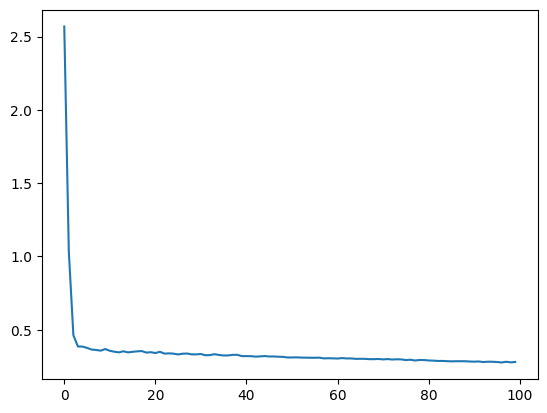

In [49]:
plt.plot( epoch_loss)

In [63]:
savepath = os.path.join('data/super/DC3/Layers4/hidden_dim50/obj001_LR0005_10epochs.pth')
torch.save(solver_net.state_dict(), savepath)   

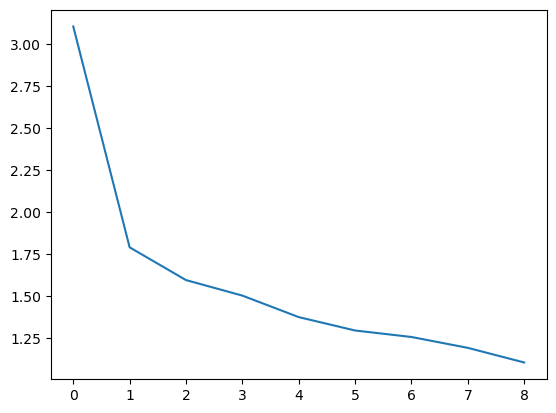

In [51]:
plt.plot(epoch_loss[1:])

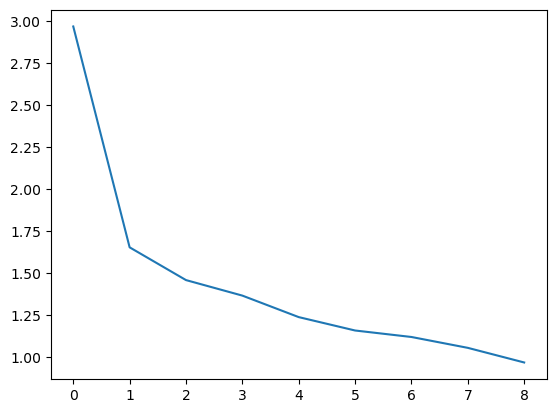

In [52]:
plt.plot(epoch_loss_unsuper[1:])

In [54]:
solver_net.eval()

test_dataset = TensorDataset(data.testX, data.testY)

test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

with torch.no_grad():
    for Xtest, Ytest in test_loader:

        Xtest = Xtest.to(DEVICE)
        Ytest = Ytest.to(DEVICE)

        Yhat_test_partial = solver_net(Xtest)

        Yhat_test_partial_trans = data.complete_partial_tanh(Xtest, Yhat_test_partial) #used to satisfy the voltage magnitude constraints

        Yhat_test = PFFunction_eval(data)(Xtest, Yhat_test_partial_trans)
    

In [56]:
pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Yhat_test)

In [57]:
torch.set_printoptions(precision=8)

In [58]:
print(torch.mean(data.obj_fn(Yhat_test)))
print(torch.mean(data.obj_fn(data.testY)))
gap = 100 * torch.abs(torch.mean(data.obj_fn(Yhat_test)) - torch.mean(data.obj_fn(data.testY))) / torch.mean(data.obj_fn(data.testY))
print(gap)

tensor(13.49727154)
tensor(13.38889537)
tensor(0.80944820)


In [59]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test), dim=1)[0]))
print(np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy()))
print(100*(1 - np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy())/torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=0).shape[0]))

tensor(0.00018055)
tensor(0.61292736)
42.693653173413296
99.65458209406623


In [ ]:
# check the VM violation
print(vm_test.shape)
lower_correct = (vm_test >= data.vmin)
upper_correct = (vm_test <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Pg violation
print(pg_test.shape)
lower_correct = (pg_test >= data.pmin)
upper_correct = (pg_test <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Qg violation
print(qg_test.shape)
lower_correct = (qg_test >= data.qmin)
upper_correct = (qg_test <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Sij violation
print(bf_test.shape)
lower_correct = (bf_test >= 0)
upper_correct = (bf_test <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(high_violation_ratio)

In [ ]:
branch_nonbinding_test = torch.norm(torch.clamp(bf_test - data.bfmax, 0),dim=0).nonzero()
print(branch_nonbinding_test in branch_nonbinding)

In [ ]:
#equality 
equality_mismatch = data.eq_resid(Xtest, Yhat_test).detach()

print(torch.mean(torch.abs(equality_mismatch)))

print(torch.mean(torch.norm(equality_mismatch, dim=1)))


In [ ]:
class NNSolver_eval(nn.Module):
    def __init__(self, data, args):
        super().__init__()
        self._data = data
        self._args = args
        
        output_dim = data.ydim - data.nknowns
        
        self.layers1 = nn.Linear(data.nbus*2, self._args['hiddenSize'])
        
        self.relu = nn.ReLU(inplace=True)
        
        self.layers2 = nn.Linear(self._args['hiddenSize'], data.npv*2+1)

        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers3(out)
        
        out = self.relu(out)
        
        out = self.layers2(out)

#         out = nn.Tanh()(out)   # used to interpolate between max and min values

        return out

In [ ]:
solver_net_eval = NNSolver_eval(data, args)
solver_net_eval.to(DEVICE)
savepath = os.path.join('data/super/hid50_soft001_full linear_equality_fulllinear_Super1_lr00001_supervised_epoch100.pth')
solver_net_eval.load_state_dict(torch.load(savepath))

Yhat_test_partial = solver_net_eval(testX_new)
Yhat_test_partial_unseen = solver_net_eval(data_basic.X[-2000:,:])

In [ ]:
Yhat_test_partial

In [ ]:
samplenumber = testX_new.shape[0]
print(samplenumber)

In [ ]:
Yhat_test_partial_unseen

In [ ]:
# the second PP obly considers inequality constraints including input including sigmoid
test_dataset_PP3_unseen = TensorDataset(data_basic.X[-2000:,:], Yhat_test_partial_unseen)

opt_batch_size = 80
test_loader_PP3_unseen = DataLoader(test_dataset_PP3_unseen, batch_size=opt_batch_size)

Yhat_partial_test_sig_PP3_unseen = torch.zeros(Yhat_test_partial_unseen.shape) # partial set before sigmoid
Yhat_partial_test_PP3_unseen = torch.zeros(Yhat_test_partial.shape) # partial set after sigmoid
Yhat_test_PP3_unseen = torch.zeros(Yhat_test_partial.shape[0], data.ydim) # full set 

opt_step = 5
opt_lr = 0.0007
b = 0

In [ ]:
# the first PP obly considers inequality constraints excluding input
start_time = time.time()
for Xtest_PP_unseen, Ytest_partial_PP_unseen in test_loader_PP3_unseen:
    Xtest_PP_unseen = Xtest_PP_unseen.to(DEVICE)
    Ytest_partial_PP_unseen = Ytest_partial_PP_unseen.to(DEVICE).clone().detach().requires_grad_(True)
    opt = optim.Adam([Ytest_partial_PP_unseen], lr = opt_lr)
    
    for i in range(opt_step):
        
        Ytest_partial_PP1_unseen = nn.Tanh()(Ytest_partial_PP_unseen) 
        
        Yhat_test_partial_trans_unseen = data.complete_partial_tanh(Xtest_PP_unseen, Ytest_partial_PP1_unseen) 
        
        Yhat_test1_unseen = PFFunction(data)(Xtest_PP_unseen, Yhat_test_partial_trans_unseen)

        ineq_cost = torch.norm(data.ineq_dist3(Xtest_PP_unseen, Yhat_test1_unseen), dim=1).mean()

        opt.zero_grad()

        ineq_cost.backward()

        opt.step() 
        
    Yhat_partial_test_sig_PP3_unseen[b:b+opt_batch_size] = Ytest_partial_PP1_unseen
#     Yhat_partial_test_PP3_unseen[b:b+opt_batch_size] = Yhat_test_partial_trans_unseen
#     Yhat_test_PP3_unseen[b:b+opt_batch_size, :data.ng*2+data.nbus*2] = Yhat_test1_unseen[:, :data.ng*2+data.nbus*2]
    
#     Pf_unseen, Qf_unseen = data.eq_resid_bf(Xtest_PP_unseen, Yhat_test1_unseen)
#     Yhat_test_PP3_unseen[b:b+opt_batch_size, data.bf_start_yidx:] = torch.square(Pf_unseen) + torch.square(Qf_unseen)
        
    b = b + opt_batch_size
    
train_time = time.time() - start_time
print(train_time)

In [ ]:
# the second PP obly considers inequality constraints including input including sigmoid
test_dataset_PP3 = TensorDataset(testX_new, Yhat_test_partial)

opt_batch_size = 80
test_loader_PP3 = DataLoader(test_dataset_PP3, batch_size=opt_batch_size)

Yhat_partial_test_sig_PP3 = torch.zeros(Yhat_test_partial.shape) # partial set before sigmoid
Yhat_partial_test_PP3 = torch.zeros(Yhat_test_partial.shape) # partial set after sigmoid
Yhat_test_PP3 = torch.zeros(Yhat_test_partial.shape[0], data.ydim) # full set 

opt_step = 10
opt_lr = 0.0007
b = 0

In [ ]:
# the first PP obly considers inequality constraints excluding input
start_time = time.time()
for Xtest_PP, Ytest_partial_PP in test_loader_PP3:
    Xtest_PP = Xtest_PP.to(DEVICE)
    Ytest_partial_PP = Ytest_partial_PP.to(DEVICE).clone().detach().requires_grad_(True)
    opt = optim.Adam([Ytest_partial_PP], lr = opt_lr)
    
    for i in range(opt_step):
        
        Ytest_partial_PP1 = nn.Tanh()(Ytest_partial_PP) 
        
        Yhat_test_partial_trans = data.complete_partial_tanh(Xtest_PP, Ytest_partial_PP1) 
        
        Yhat_test1 = PFFunction(data)(Xtest_PP, Yhat_test_partial_trans)

        ineq_cost = torch.norm(data.ineq_dist3(Xtest_PP, Yhat_test1), dim=1).mean()

        opt.zero_grad()

        ineq_cost.backward()

        opt.step() 
        
    Yhat_partial_test_sig_PP3[b:b+opt_batch_size] = Ytest_partial_PP1
    Yhat_partial_test_PP3[b:b+opt_batch_size] = Yhat_test_partial_trans
    Yhat_test_PP3[b:b+opt_batch_size, :data.ng*2+data.nbus*2] = Yhat_test1[:, :data.ng*2+data.nbus*2]
    
    Pf, Qf = data.eq_resid_bf(Xtest_PP, Yhat_test1)
    Yhat_test_PP3[b:b+opt_batch_size, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
        
    b = b + opt_batch_size
train_time = time.time() - start_time
print(train_time)

In [ ]:
train_time/60

In [ ]:
samplenumber = Xtest.shape[0]

In [ ]:
#original
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test[:samplenumber,:])))
print(torch.mean(data.obj_fn(data.testY[-800:, :])))

In [ ]:
(13.3980 - 13.3903) / 13.3903

In [ ]:
data.testY[-800:, :].shape

In [ ]:
#original lr = 0.0007, step 10
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP3[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP3[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test_PP3[:samplenumber,:])))

In [ ]:
pg_test_PP3, qg_test_PP3, vm_test_PP3, va_test_PP3, bf_test_PP3 = data.get_yvars(Yhat_test_PP3[:samplenumber,:])

In [ ]:
# check the Pg violation
print(pg_test_PP3.shape)
lower_correct = (pg_test_PP3 >= data.pmin)
upper_correct = (pg_test_PP3 <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(lower_correct.shape[0] * lower_correct.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(upper_correct.shape[0] * upper_correct.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Qg violation
print(qg_test_PP3.shape)
lower_correct = (qg_test_PP3 >= data.qmin)
upper_correct = (qg_test_PP3 <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test_PP3.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test_PP3.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
print(torch.norm(torch.clamp(data.qmin - qg_test, 0),dim=0).mean())
print(torch.norm(torch.clamp(qg_test - data.qmax, 0),dim=0).mean())

In [ ]:
print(torch.norm(torch.clamp(data.qmin - qg_test_PP3, 0),dim=0).mean())
print(torch.norm(torch.clamp(qg_test_PP3 - data.qmax, 0),dim=0).mean())

In [ ]:
# check the VM violation
print(vm_test_PP3.shape)
lower_correct = (vm_test_PP3 >= data.vmin)
upper_correct = (vm_test_PP3 <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(high_violation_ratio)

In [ ]:
torch.norm(torch.clamp(vm_test - data.vmax, 0),dim=0).mean()

In [ ]:
torch.norm(torch.clamp(vm_test_PP3 - data.vmax, 0),dim=0).mean()

In [ ]:
# check the Sij violation
print(bf_test_PP3.shape)
lower_correct = (bf_test_PP3 >= 0)
upper_correct = (bf_test_PP3 <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(bf_test_PP3.shape[0] * bf_test_PP3.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(bf_test_PP3.shape[0] * bf_test_PP3.shape[1])
print(high_violation_ratio)

In [ ]:
torch.norm(torch.clamp(bf_test - data.bfmax, 0),dim=0).mean()

In [ ]:
torch.norm(torch.clamp(bf_test_PP3 - data.bfmax, 0),dim=0).mean()

In [ ]:
samplenumber = 16
Yhat_test_partial = Yhat_test_partial[:samplenumber, :]

In [ ]:
# the second PP obly considers inequality constraints including input including sigmoid, obj
test_dataset_PP4 = TensorDataset(data.X[:samplenumber, :], Yhat_test_partial)

opt_batch_size = 16
test_loader_PP4 = DataLoader(test_dataset_PP4, batch_size=opt_batch_size)

Yhat_partial_test_sig_PP4 = torch.zeros(Yhat_test_partial.shape) # partial set before sigmoid
Yhat_partial_test_PP4 = torch.zeros(Yhat_test_partial.shape) # partial set after sigmoid
Yhat_test_PP4 = torch.zeros(Yhat_test_partial.shape[0], data.ydim) # full set 

opt_step = 10
opt_lr = 0.0001
b = 0

In [ ]:
# the first PP obly considers inequality constraints excluding input
start_time = time.time()
for Xtest_PP, Ytest_partial_PP in test_loader_PP4:
    Xtest_PP = Xtest_PP.to(DEVICE)
    Ytest_partial_PP = Ytest_partial_PP.to(DEVICE).clone().detach().requires_grad_(True)
    opt = optim.Adam([Ytest_partial_PP], lr = opt_lr)
    
    for i in range(opt_step):
        
        Ytest_partial_PP1 = nn.Tanh()(Ytest_partial_PP) 
        
        Yhat_test_partial_trans = data.complete_partial_tanh(Xtest_PP, Ytest_partial_PP1) 
        
        Yhat_test1 = PFFunction(data)(Xtest_PP, Yhat_test_partial_trans)
        
        obj_cost = data.obj_fn(Yhat_test1).mean()
        
        ineq_cost = torch.norm(data.ineq_dist3(Xtest_PP, Yhat_test1), dim=1).mean() 
        
        opt.zero_grad()

        ineq_cost.backward()

        opt.step() 
    
    Yhat_partial_test_sig_PP4[b:b+opt_batch_size] = Ytest_partial_PP1
    Yhat_partial_test_PP4[b:b+opt_batch_size] = Yhat_test_partial_trans
    Yhat_test_PP4[b:b+opt_batch_size, :data.ng*2+data.nbus*2] = Yhat_test1[:, :data.ng*2+data.nbus*2]
    
    Pf, Qf = data.eq_resid_bf(Xtest_PP, Yhat_test1)
    Yhat_test_PP4[b:b+opt_batch_size, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)

    b = b + opt_batch_size
train_time = time.time() - start_time
print(train_time)

In [ ]:
#original lr = 0.0007, step 5
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP4[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP4[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test_PP4[:samplenumber,:])))

In [ ]:
pg_test_PP4, qg_test_PP4, vm_test_PP4, va_test_PP4, bf_test_PP4 = data.get_yvars(Yhat_test_PP4)

In [ ]:
# check the Qg violation
print(qg_test_PP4.shape)
lower_correct = (qg_test_PP4 >= data.qmin)
upper_correct = (qg_test_PP4 <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test_PP4.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test_PP4.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Yhat_test)
vm_test_mean = vm_test.mean(dim=0)
va_test_mean = va_test.mean(dim=0)

In [ ]:
qg_test_PP4 

In [ ]:
qg_test

In [ ]:
#optimize the coding
def PFFunction(data, tol=1e-5, bsz=16, bsz2=16, max_iters=30):
    class PFFunctionFn(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim - data.nbr + data.nbr_reduced, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
            Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])

            newton_jacs_inv = []

            bf_grad = []
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va, _ = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
#                     if torch.norm(data.eq_resid(X_b, Y_b)[:, keep_constr]) < tol:
#                         break
                    
                    # print(torch.norm(data.eq_resid(X_b, Y_b)[:, keep_constr]))
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break
                    
#                 jac_full_reduced = data.eq_jac_LR_full2(Y_b, Weights_equality_linear_full) 
                # jacs.append(jac_full)

                ## Step 2: Solve for remaining variables
#                 equality_resid_b = -data.eq_resid(X_b, Y_b)

                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
            Pf_reduced, Qf_reduced = data.eq_resid_bf_reduced(X, Y)

            Y[:, data.bf_start_yidx:] = torch.square(Pf_reduced) + torch.square(Qf_reduced)

            eq_jac_tmp = data.eq_jac_pfqf_LR_full_reduced(Y, WeightMatrix_linear_full_reduced)

            eq_jac_bf_tmp = data.eq_jac_bf_modi2_reduced(Y, Pf_reduced, Qf_reduced, eq_jac_tmp)
            
            jac_full_reduced = data.eq_jac_LR_full3(Y, Weights_equality_linear_full)
            jac3s = jac_full_reduced[last_eqs, data.vm_start_yidx-data.ng*2:]
            jac2s_reduced = jac_full_reduced[keep_constr, :]
                
            ctx.data = data

            ctx.save_for_backward(jac2s_reduced, jac3s,
                torch.tensor(newton_guess_inds, device = data.device), 
                torch.tensor(keep_constr, device = data.device), eq_jac_bf_tmp)
            
            return Y

        @staticmethod
        def backward(ctx, dl_dy):
            data = ctx.data
            # jac, newton_guess_inds, keep_constr, bf_grad = ctx.saved_tensors
            jac2_reduced, jac3, newton_guess_inds, keep_constr, eq_jac_bf_tmp  = ctx.saved_tensors
            ## Step 2 (calc pg at slack and qg at gens)
            
            # gradient of all voltages through step 3 outputs, for Z_2
            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            last_vars = np.concatenate([
                data.pg_start_yidx + data.slack_, np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)])
            # jac3 = jac[:, last_eqs, :]
            
            dl_dvmva_3 = dl_dy[:, last_vars].mm(-jac3)
            
            dl_dvmva_4tt1 = eq_jac_bf_tmp[:, :data.nbr_reduced] * dl_dy[:, -data.nbr_reduced:]
            dl_dvmva_4tt2 = eq_jac_bf_tmp[:, data.nbr_reduced:data.nbr_reduced*2] * dl_dy[:, -data.nbr_reduced:]
            dl_dvmva_4tt3 = eq_jac_bf_tmp[:, data.nbr_reduced*2:data.nbr_reduced*3] * dl_dy[:, -data.nbr_reduced:]
            
            # gradient of pd at slack and qd at gens through step 3 outputs
#             dl_dpdqd_3 = dl_dy[:, last_vars]

            # insert into correct places in x and y loss vectors
#             dl_dy_3 = torch.zeros(dl_dy.shape, device = data.device)
#             dl_dy_3[:, data.vm_start_yidx:-data.nbr] = dl_dvmva_3
            
            from_shape_reduced = visit_list_F_reduced.shape[0]
            to_shape_reduced = visit_list_T_reduced.shape[0]
            
#             # insert into correct places in x and y loss vectors
            dl_dy_4_test_reduced = torch.zeros(dl_dy.shape[0], data.nbus*2, device = data.device)
            
            dl_dy_4_test1 = torch.zeros(dl_dy.shape[0], from_shape_reduced)
            dl_dy_4_test2 = torch.zeros(dl_dy.shape[0], to_shape_reduced)
            dl_dy_4_test3 = torch.zeros(dl_dy.shape[0], from_shape_reduced)
            dl_dy_4_test4 = torch.zeros(dl_dy.shape[0], to_shape_reduced)
            
            for i in range(from_shape_reduced):
                dl_dy_4_test1[:, i] = torch.sum(dl_dvmva_4tt1[:, connect_branch_F_reduced[i]], dim = 1)
                dl_dy_4_test3[:, i] = torch.sum(dl_dvmva_4tt3[:, connect_branch_F_reduced[i]], dim = 1)

            for i in range(to_shape_reduced):
                dl_dy_4_test2[:, i] = torch.sum(dl_dvmva_4tt2[:, connect_branch_T_reduced[i]], dim = 1)
                dl_dy_4_test4[:, i] = torch.sum(-dl_dvmva_4tt3[:, connect_branch_T_reduced[i]], dim = 1)
            
            dl_dy_4_test_reduced[:, data.vm_start_yidx + visit_list_F_reduced - data.ng*2] = dl_dy_4_test1
            dl_dy_4_test_reduced[:, data.vm_start_yidx + visit_list_T_reduced - data.ng*2] = dl_dy_4_test2 + dl_dy_4_test_reduced[:, data.vm_start_yidx + visit_list_T_reduced - data.ng*2] 
            
            dl_dy_4_test_reduced[:, data.va_start_yidx + visit_list_F_reduced - data.ng*2] = dl_dy_4_test3
            dl_dy_4_test_reduced[:, data.va_start_yidx + visit_list_T_reduced - data.ng*2] = dl_dy_4_test4 + dl_dy_4_test_reduced[:, data.va_start_yidx + visit_list_T_reduced - data.ng*2]

            
#             dl_dx_3 = torch.zeros(dl_dy.shape[0], data.xdim, device = data.device)
#             dl_dx_3[:, np.concatenate([data.slack, data.nbus + data.spv])] = dl_dpdqd_3

            dl_dy[:, data.vm_start_yidx:-data.nbr_reduced] = dl_dy_4_test_reduced + dl_dy[:, data.vm_start_yidx:-data.nbr_reduced] \
            + dl_dvmva_3
            
            dl_dy_total = dl_dy
            
            jac_newton = jac2_reduced[:, newton_guess_inds-data.ng*2].transpose(0,1) 
            
            d_int = torch.linalg.solve(jac_newton, dl_dy_total[:, newton_guess_inds].transpose(0,1)).transpose(0,1).to(data.device)
            
            dl_dz_2 = torch.zeros(dl_dy.shape[0], data.npv + data.ng, device = data.device)
            dl_dz_2[:, data.pg_pv_zidx] = -d_int[:, :data.npv]  # dl_dpg at pv buses
            dl_dz_2[:, data.vm_spv_zidx] = d_int.mm(-jac2_reduced[:, data.vm_start_yidx + data.spv-data.ng*2])

        
#             dl_dx_2 = torch.zeros(dl_dy.shape[0], data.xdim, device = data.device)
#             dl_dx_2[:, data.pv] = d_int[:, :data.npv]                       # dl_dpd at pv buses
#             dl_dx_2[:, data.pq] = d_int[:, data.npv:data.npv+len(data.pq)]  # dl_dpd at pq buses
#             dl_dx_2[:, data.nbus + data.pq] = d_int[:, -len(data.pq):]      # dl_dqd at pq buses

            # Final quantities
#             dl_dx_total = dl_dx_3 + dl_dx_2
            dl_dz_total = dl_dz_2 + dl_dy_total[:, np.concatenate([
                data.pg_start_yidx + data.pv_, data.vm_start_yidx + data.spv])]
#             return dl_dx_total, dl_dz_total
            return None, dl_dz_total


    return PFFunctionFn.apply

In [ ]:
#optimize the coding
def PFFunction_PP(data, tol=1e-5, bsz=16, bsz2=16, max_iters=30):
    class PFFunctionFn_PP(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim - data.nbr + data.nbr_reduced, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
            Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            keep_constr_reduced = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + np.arange(data.pq.shape[0])])    # reactive power flow at load buses
            
            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            
            last_eqs_slack = data.pflow_start_eqidx + data.slack
            
            newton_jacs_inv = []

            bf_grad = []
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va, _ = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
#                     if torch.norm(data.eq_resid(X_b, Y_b)[:, keep_constr]) < tol:
#                         break
                    
                    # print(torch.norm(data.eq_resid(X_b, Y_b)[:, keep_constr]))
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break
                    
#                 jac_full_reduced = data.eq_jac_LR_full2(Y_b, Weights_equality_linear_full) 
                # jacs.append(jac_full)

                ## Step 2: Solve for remaining variables
#                 equality_resid_b = -data.eq_resid(X_b, Y_b)

                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
            Pf_reduced, Qf_reduced = data.eq_resid_bf_reduced(X, Y)

            Y[:, data.bf_start_yidx:] = torch.square(Pf_reduced) + torch.square(Qf_reduced)

            eq_jac_tmp = data.eq_jac_pfqf_LR_full_reduced(Y, WeightMatrix_linear_full_reduced)

            eq_jac_bf_tmp = data.eq_jac_bf_modi2_reduced(Y, Pf_reduced, Qf_reduced, eq_jac_tmp)
            
            jac_full_reduced = data.eq_jac_LR_full4(Y, Weights_equality_linear_full)
            
            jac3s = jac_full_reduced[last_eqs_slack, data.vm_start_yidx-data.ng*2:]
            jac2s_reduced = jac_full_reduced[keep_constr_reduced, :]
            
            jac_Qgs = data.eq_jac_LR_full5(Y, vm_test_mean, va_test_mean)
            
            ctx.data = data

            ctx.save_for_backward(jac2s_reduced, jac3s, jac_Qgs,
                torch.tensor(newton_guess_inds, device = data.device), 
                torch.tensor(keep_constr_reduced, device = data.device), eq_jac_bf_tmp)
            
            return Y

        @staticmethod
        def backward(ctx, dl_dy):
            data = ctx.data
            # jac, newton_guess_inds, keep_constr, bf_grad = ctx.saved_tensors
            jac2_reduced, jac3, jac_Qg,  newton_guess_inds, keep_constr_reduced, eq_jac_bf_tmp  = ctx.saved_tensors
            ## Step 2 (calc pg at slack and qg at gens)
            
            # gradient of all voltages through step 3 outputs, for Z_2
            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            
            last_eqs_slack = data.pflow_start_eqidx + data.slack
            
            last_vars = np.concatenate([
                data.pg_start_yidx + data.slack_, np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)])
            
            last_vars_slack = data.pg_start_yidx + data.slack_ 
            
            last_vars_qg = np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)
            
            # jac3 = jac[:, last_eqs, :]
            
            dl_dvmva_3_slack = dl_dy[:, last_vars_slack].mm(-jac3)
            dl_dvm_3_qg = -jac_Qg.transpose(1,2).bmm(dl_dy[:, last_vars_qg].unsqueeze(-1)).squeeze(-1)
            
            dl_dvmva_4tt1 = eq_jac_bf_tmp[:, :data.nbr_reduced] * dl_dy[:, -data.nbr_reduced:]
            dl_dvmva_4tt2 = eq_jac_bf_tmp[:, data.nbr_reduced:data.nbr_reduced*2] * dl_dy[:, -data.nbr_reduced:]
            dl_dvmva_4tt3 = eq_jac_bf_tmp[:, data.nbr_reduced*2:data.nbr_reduced*3] * dl_dy[:, -data.nbr_reduced:]
            
            # gradient of pd at slack and qd at gens through step 3 outputs
#             dl_dpdqd_3 = dl_dy[:, last_vars]

            # insert into correct places in x and y loss vectors
#             dl_dy_3 = torch.zeros(dl_dy.shape, device = data.device)
#             dl_dy_3[:, data.vm_start_yidx:-data.nbr] = dl_dvmva_3
            
            from_shape_reduced = visit_list_F_reduced.shape[0]
            to_shape_reduced = visit_list_T_reduced.shape[0]
            
#             # insert into correct places in x and y loss vectors
            dl_dy_4_test_reduced = torch.zeros(dl_dy.shape[0], data.nbus*2, device = data.device)
            
            dl_dy_4_test1 = torch.zeros(dl_dy.shape[0], from_shape_reduced)
            dl_dy_4_test2 = torch.zeros(dl_dy.shape[0], to_shape_reduced)
            dl_dy_4_test3 = torch.zeros(dl_dy.shape[0], from_shape_reduced)
            dl_dy_4_test4 = torch.zeros(dl_dy.shape[0], to_shape_reduced)
            
            for i in range(from_shape_reduced):
                dl_dy_4_test1[:, i] = torch.sum(dl_dvmva_4tt1[:, connect_branch_F_reduced[i]], dim = 1)
                dl_dy_4_test3[:, i] = torch.sum(dl_dvmva_4tt3[:, connect_branch_F_reduced[i]], dim = 1)

            for i in range(to_shape_reduced):
                dl_dy_4_test2[:, i] = torch.sum(dl_dvmva_4tt2[:, connect_branch_T_reduced[i]], dim = 1)
                dl_dy_4_test4[:, i] = torch.sum(-dl_dvmva_4tt3[:, connect_branch_T_reduced[i]], dim = 1)
            
            dl_dy_4_test_reduced[:, data.vm_start_yidx + visit_list_F_reduced - data.ng*2] = dl_dy_4_test1
            dl_dy_4_test_reduced[:, data.vm_start_yidx + visit_list_T_reduced - data.ng*2] = dl_dy_4_test2 + dl_dy_4_test_reduced[:, data.vm_start_yidx + visit_list_T_reduced - data.ng*2] 
            
            dl_dy_4_test_reduced[:, data.va_start_yidx + visit_list_F_reduced - data.ng*2] = dl_dy_4_test3
            dl_dy_4_test_reduced[:, data.va_start_yidx + visit_list_T_reduced - data.ng*2] = dl_dy_4_test4 + dl_dy_4_test_reduced[:, data.va_start_yidx + visit_list_T_reduced - data.ng*2]

            
#             dl_dx_3 = torch.zeros(dl_dy.shape[0], data.xdim, device = data.device)
#             dl_dx_3[:, np.concatenate([data.slack, data.nbus + data.spv])] = dl_dpdqd_3

            dl_dy[:, data.vm_start_yidx:-data.nbr_reduced] = dl_dy_4_test_reduced + dl_dy[:, data.vm_start_yidx:-data.nbr_reduced] \
            + dl_dvmva_3_slack 
    
            dl_dy[:, data.vm_start_yidx:data.vm_start_yidx + data.nbus] = dl_dy[:, data.vm_start_yidx:data.vm_start_yidx + data.nbus] \
            + dl_dvm_3_qg
            
            dl_dy_total = dl_dy
            
            jac_newton = jac2_reduced[:, newton_guess_inds-data.ng*2].transpose(0,1) 
            
            d_int = torch.linalg.solve(jac_newton, dl_dy_total[:, newton_guess_inds].transpose(0,1)).transpose(0,1).to(data.device)
            
            dl_dz_2 = torch.zeros(dl_dy.shape[0], data.npv + data.ng, device = data.device)
            dl_dz_2[:, data.pg_pv_zidx] = -d_int[:, :data.npv]  # dl_dpg at pv buses
            dl_dz_2[:, data.vm_spv_zidx] = d_int.mm(-jac2_reduced[:, data.vm_start_yidx + data.spv-data.ng*2])

        
#             dl_dx_2 = torch.zeros(dl_dy.shape[0], data.xdim, device = data.device)
#             dl_dx_2[:, data.pv] = d_int[:, :data.npv]                       # dl_dpd at pv buses
#             dl_dx_2[:, data.pq] = d_int[:, data.npv:data.npv+len(data.pq)]  # dl_dpd at pq buses
#             dl_dx_2[:, data.nbus + data.pq] = d_int[:, -len(data.pq):]      # dl_dqd at pq buses

            # Final quantities
#             dl_dx_total = dl_dx_3 + dl_dx_2
            dl_dz_total = dl_dz_2 + dl_dy_total[:, np.concatenate([
                data.pg_start_yidx + data.pv_, data.vm_start_yidx + data.spv])]
#             return dl_dx_total, dl_dz_total
            return None, dl_dz_total


    return PFFunctionFn_PP.apply

In [ ]:
# finish the post-processing
def PFFunction_pgqg(data, tol=1e-5, bsz=128, max_iters=10):
    class PFFunctionFn_pgqg(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=data.device)
            
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
#             Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_start_yidx + data.pv_]   # pg at non-slack gens
#             Y[:, data.qg_start_yidx + data.pv_] = Z[:, data.qg_start_yidx + data.pv_]   # qg at non-slack gens
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_zidx]   # pg at all gens
            Y[:, data.qg_start_yidx + data.allgen_idxes] = Z[:, data.qg_zidx]   # qg at all gens
        
            # init guesses for the slack bus
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device)  # va at slack bus
            Y[:, data.vm_start_yidx + data.slack] = torch.tensor(data.vm_init[data.slack], device=data.device)  # vm at slack bus
            
            # init guesses for remaining buses
            Y[:, data.vm_start_yidx + data.nonslack_idxes] = torch.tensor(data.vm_init[data.nonslack_idxes], device=data.device)   # vm at load buses
            Y[:, data.va_start_yidx + data.nonslack_idxes] = torch.tensor(data.va_init[data.nonslack_idxes], device=data.device)  # va at non-slack gens 
            
#             Y[:, data.qg_start_yidx+data.slack_] = 0    # qg at slack (not used in Newton upd)
#             Y[:, data.pg_start_yidx+data.slack_] = 0    # pg at slack (not used in Newton upd)

#             keep_constr = np.concatenate([
#                 data.pflow_start_eqidx + data.nonslack_idxes,     # real power flow at all buses
#                 data.qflow_start_eqidx + data.nonslack_idxes])    # reactive power flow at all buses
            
#             newton_guess_inds = np.concatenate([             
#                 data.vm_start_yidx + data.nonslack_idxes,         # vm at non-slack buses
#                 data.va_start_yidx + data.nonslack_idxes])         # va at non-slack buses

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.nonslack_idxes, # real power flow at all non-slack buses 
                data.qflow_start_eqidx + data.allbus_idxes])    # reactive power flow at all buses
            
            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.allbus_idxes,         # vm at all buses
                data.va_start_yidx + data.nonslack_idxes])  # va at non-slack buses
            
            global flag 
            flag = 0
            converged = torch.zeros(X.shape[0])
            jacs = []
            newton_jacs_inv = []
            
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]
                #initial mismatch
                gy_all = data.eq_resid(X_b, Y_b)
                for i in range(max_iters):
#                     print(i)
                    gy = gy_all[:, keep_constr]
                    jac_full = data.eq_jac(Y_b)
                    jac = jac_full[:, keep_constr, :]
                    newton_jac_inv = torch.inverse(jac[:, :, newton_guess_inds])
                    delta = newton_jac_inv.bmm(gy.unsqueeze(-1)).squeeze(-1)
                    Y_b[:, newton_guess_inds] -= delta
#                     Y_b[:, data.vm_start_yidx + data.nonslack_idxes] = torch.clamp(Y_b[:, data.vm_start_yidx + data.nonslack_idxes], lower, upper)
                    gy_all = data.eq_resid(X_b, Y_b)    
                    if torch.norm(gy_all[:, keep_constr]) < tol:
                        flag = 1
                        break
                
                ## Step 2: Solve for remaining variables
                Y_b[:, data.pg_start_yidx + data.slack_] = -gy_all[:, data.pflow_start_eqidx + data.slack]   
                # calculate the branch flow            
                Pf, Qf = data.eq_resid_bf(X, Y)
                Y[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
            
            return Y

    return PFFunctionFn_pgqg.apply

In [ ]:
# power generation input to PF solver
pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Ytest)
PgQg_test = torch.cat((pg_test[:, data.pv_], qg_test), dim=1)
# build the full set of the random variable
Yhat_test = PFFunction_pgqg(data)(Xtest, PgQg_test)

In [ ]:
pg_test_pp, qg_test_pp, vm_test_pp, va_test_pp, bf_test_pp = data.get_yvars(Yhat_test)

In [ ]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test), dim=1)[0]))

In [ ]:
torch.mean(data.obj_fn(Yhat_test))

In [ ]:
# power generation input to PF solver
pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Ytest)
# clamp the pgand qg
pg_test = torch.clamp(pg_test, min = data.pmin, max = data.pmax)
qg_test = torch.clamp(qg_test, min = data.qmin, max = data.qmax)
PgQg_test = torch.cat((pg_test[:, data.pv_], qg_test), dim=1)
# build the full set of the random variable
Yhat_test_clamp = PFFunction_pgqg(data)(Xtest, PgQg_test)

In [ ]:
# torch.save(solver_net.state_dict(), savepath)

In [ ]:
# solver_net.load_state_dict(torch.load(savepath))

In [ ]:
pg_test_clamp, qg_test_clamp, vm_test_clamp, va_test_clamp, bf_test_clamp = data.get_yvars(Yhat_test_clamp)

In [ ]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test_clamp), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test_clamp), dim=1)[0]))

In [ ]:
# check the Pg violation
print(pg_test.shape)
lower_correct = (pg_test_clamp>= data.pmin)
upper_correct = (pg_test_clamp <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Qg violation
print(qg_test.shape)
lower_correct = (qg_test_clamp >= data.qmin)
upper_correct = (qg_test_clamp <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the VM violation
print(vm_test.shape)
lower_correct = (vm_test_clamp >= data.vmin)
upper_correct = (vm_test_clamp <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Sij violation
print(bf_test_clamp.shape)
lower_correct = (bf_test_clamp >= 0)
upper_correct = (bf_test_clamp <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(high_violation_ratio)

In [ ]:
pg_matpower, qg_matpower, vm_matpower, va_matpower = data.get_yvars(data.testY) 
bf_matpower = BFFunction(data)(data.testY)

In [ ]:
torch.mean(data.obj_fn(data.testY))

In [ ]:
# check the VM violation
print(vm_matpower.shape)
lower_correct = (vm_matpower >= data.vmin)
upper_correct = (vm_matpower <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*30)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*30)
print(high_violation_ratio)

In [ ]:
# check the Pg violation
print(pg_matpower.shape)
lower_correct = (pg_matpower >= data.pmin)
upper_correct = (pg_matpower <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*6)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*6)
print(high_violation_ratio)

In [ ]:
# check the Qg violation
print(qg_matpower.shape)
lower_correct = (qg_matpower >= data.qmin)
upper_correct = (qg_matpower <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*6)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*6)
print(high_violation_ratio)

In [ ]:
# check the Sij violation
print(bf_matpower.shape)
lower_correct = (bf_matpower >= 0)
upper_correct = (bf_matpower <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*41)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*41)
print(high_violation_ratio)